## Modelagem Random Forest

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    recall_score,
)

from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
# calc mean
nums = [3500, 2800, 4000, 5000, 10000, 2000, 1600, 1000000000]
mean = sum(nums) / len(nums)
print(mean)

125003612.5


In [4]:
df = pd.read_csv('../data/processed/pns_2019_final.csv')
df.shape

(87657, 78)

In [5]:
df = df.dropna(subset=['hipertensao'])
df['hipertensao'].shape

(85995,)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 85995 entries, 0 to 87656
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   situacao_domicilio      85995 non-null  int64  
 1   acesso_internet         85995 non-null  int64  
 2   plano_saude             85995 non-null  float64
 3   hipertensao             85995 non-null  float64
 4   diabetes                80927 non-null  float64
 5   doenca_coracao          85995 non-null  float64
 6   infarto                 85995 non-null  float64
 7   angina                  85995 non-null  float64
 8   insuficiencia_cardiaca  85995 non-null  float64
 9   arritmia                85995 non-null  float64
 10  avc                     85995 non-null  float64
 11  asma                    85995 non-null  float64
 12  artrite                 85995 non-null  float64
 13  dort                    85995 non-null  float64
 14  depressao               85995 non-null  float64
 15  d

In [7]:
# Contagem absoluta
contagem = df["hipertensao"].value_counts(dropna=False)

# Proporção
proporcao = (
    df["hipertensao"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

resumo = pd.DataFrame({
    "qtd": contagem,
    "percentual_%": proporcao
})

resumo

,qtd,percentual_%
hipertensao,,
0.0,62279,72.42
1.0,23716,27.58


In [8]:
df["hipertensao"].value_counts(normalize=True)

hipertensao
0.0    0.724217
1.0    0.275783
Name: proportion, dtype: float64

### Testar Interações entre Variaveis


In [9]:
# verifica valores de situacao_domicilio
# hipertensao               27.052396
# depressao                  9.329592
# diabetes                   8.352152
df["hipertensao"].value_counts()

hipertensao
0.0    62279
1.0    23716
Name: count, dtype: int64

In [10]:
# ============================================================
# 1. INTERAÇÕES
# ============================================================

# Interações com idade (efeito multiplicador)
df["esc_x_idade"] = df["escolaridade_ord"] * df["idade_c"] 
df["renda_x_idade"] = df["renda_per_capita_log"] * df["idade_c"] 
df["atividade_x_idade"] = df["atividade_ativo"] * df["idade_c"] 
df["tabagismo_x_idade"] = df["tabagismo_ativo"] * df["idade_c"] 
df["alcool_x_idade"] = df["alcool_ativo"] * df["idade_c"] 
df["imc_x_idade"] = df["imc"] * df["idade_c"]  
df["plano_x_idade"] = df["plano_saude"] * df["idade_c"]  
df["situacao_x_idade"] = df["situacao_domicilio"] * df["idade_c"]  
df["sexo_x_idade"] = df["sexo_feminino"] * df["idade_c"]

# Interações DSS ↔ IMC (mediação biomédica)
df["renda_x_imc"] = df["renda_per_capita_log"] * df["imc"]
df["esc_x_imc"] = df["escolaridade_ord"] * df["imc"]

# Interações de raça com idade
df["raca_Preta_x_idade"] = df["raca_Preta"] * df["idade_c"]
df["raca_Parda_x_idade"] = df["raca_Parda"] * df["idade_c"]
df["raca_Amarela_x_idade"] = df["raca_Amarela"] * df["idade_c"]
df["raca_Indigena_x_idade"] = df["raca_Indigena"] * df["idade_c"]

# Índice composto
df["indice_socioeconomico_x_idade"] = df["indice_socioeconomico"] * df["idade_c"]


# ============================================================
# 2. BLOCO DEMOGRÁFICO (BASE)
# ============================================================

features_base_demo = [
    "idade_c",
    "sexo_feminino",
    "raca_Preta",
    "raca_Parda",
    "raca_Amarela",
    "raca_Indigena"
]

features_x_idade_demo = [
    "sexo_x_idade",
    "raca_Preta_x_idade",
    "raca_Parda_x_idade",
    "raca_Amarela_x_idade",
    "raca_Indigena_x_idade"
]


# ============================================================
# 3. BLOCO BIOMÉDICO E COMPORTAMENTAL
# ============================================================

features_base_bio = [
    "atividade_ativo",
    "tabagismo_ativo",
    "alcool_ativo",
    "imc"
]

features_x_idade_bio = [
    "atividade_x_idade",
    "tabagismo_x_idade",
    "alcool_x_idade",
    "imc_x_idade"
]


# ============================================================
# 4. BLOCO DSS
# ============================================================

features_base_dss = [
    "escolaridade_ord", 
    "renda_per_capita_log", 
    "plano_saude",
    "situacao_domicilio",
]

features_x_idade_dss = [
    "esc_x_idade",  
    "renda_x_idade",    
    "plano_x_idade",
    "situacao_x_idade",
    "indice_socioeconomico_x_idade"
]

features_x_imc_dss = [
    "renda_x_imc",
    "esc_x_imc"
]


# ============================================================
# 5. MODELOS FINAIS
# ============================================================

# Modelo 1: Biomédico + Demográfico
features_final_bio = (
    features_base_demo +
    features_x_idade_demo +
    features_base_bio +
    features_x_idade_bio
)

# Modelo 2: DSS + Demográfico
features_final_dss = (
    features_base_demo +
    features_x_idade_demo +
    features_base_dss +
    features_x_idade_dss
)

# Modelo 3: Completo (BIO + DSS)
features_final_dss_bio = (
    features_base_demo +
    features_x_idade_demo +
    features_base_bio +
    features_x_idade_bio +
    features_base_dss +
    features_x_idade_dss +
    features_x_imc_dss
)

## Heatmap


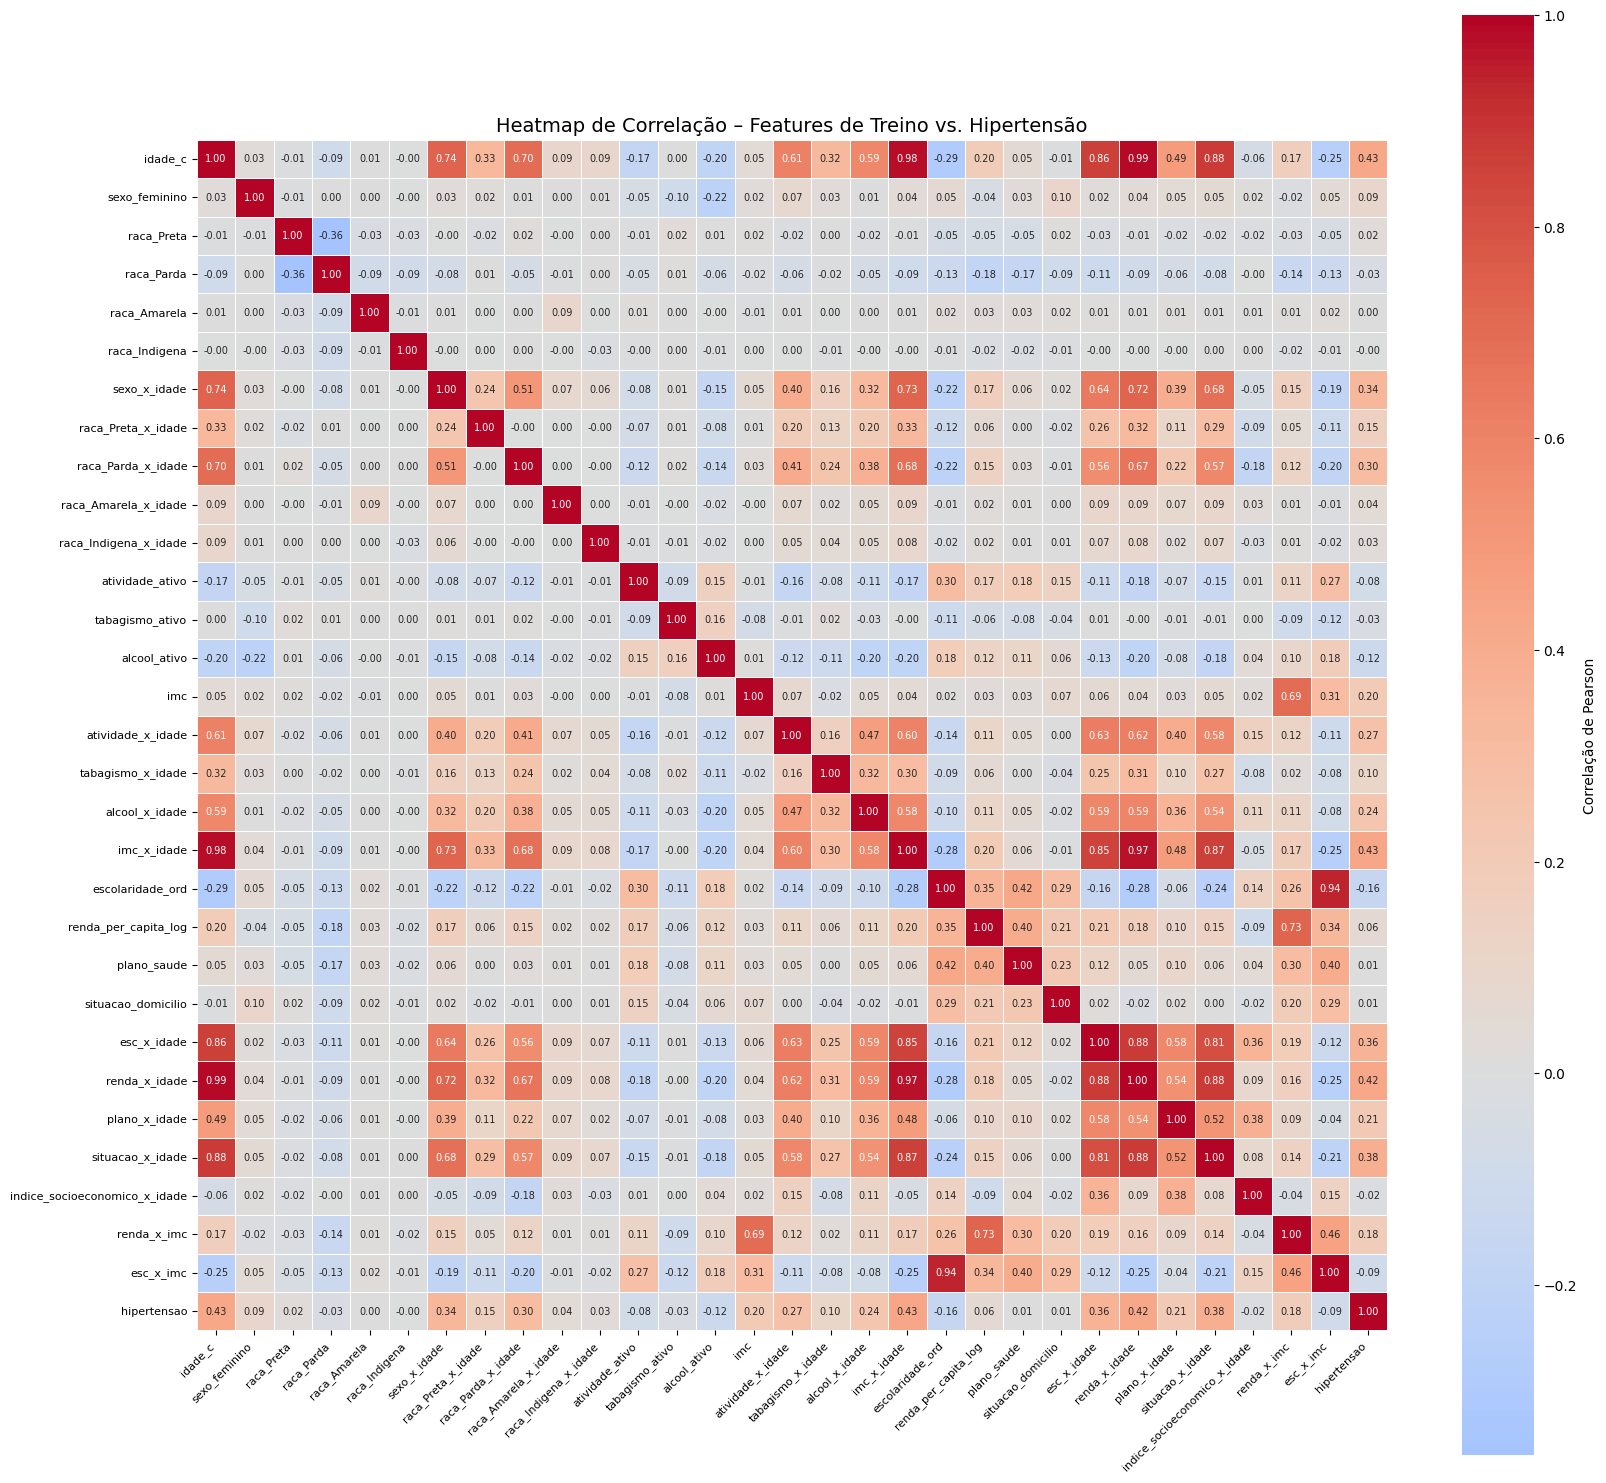

In [11]:
# União de todas as features usadas nos três blocos de treino
all_features = list(dict.fromkeys(
    features_final_bio + features_final_dss + features_final_dss_bio
))

# Subconjunto do df com as features + alvo
cols = [f for f in all_features if f in df.columns] + ["hipertensao"]
corr_matrix = df[cols].corr()

plt.figure(figsize=(max(14, len(cols) * 0.55), max(12, len(cols) * 0.5)))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    annot_kws={"size": 7},
    cbar_kws={"label": "Correlação de Pearson"},
)
plt.title("Heatmap de Correlação – Features de Treino vs. Hipertensão", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Random Forest não exige padronização e combina várias decision trees. Aqui usamos imputação + busca de hiperparâmetros com GridSearchCV.

In [12]:
X_bio = df[features_final_bio]
X_dss_bio = df[features_final_dss_bio]
X_dss = df[features_final_dss]
 

## Definir variavel alvo

In [13]:
y = df["hipertensao"]

In [14]:
print(X_bio.shape, y.shape)

(85995, 19) (85995,)


In [15]:
# Modelo 1
X_bio_train, X_bio_test, y_bio_train, y_bio_test = train_test_split(
    X_bio, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 

X_dss_bio_train, X_dss_bio_test, y_dss_bio_train, y_dss_bio_test = train_test_split(
    X_dss_bio, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_dss_train, X_dss_test, y_dss_train, y_dss_test = train_test_split(
    X_dss, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# smote = SMOTE(random_state=42)
# X_bio_resampled, y_bio_resampled = smote.fit_resample(X_bio_train, y_bio_train)
# X_dss_bio_resampled, y_dss_bio_resampled = smote.fit_resample(X_dss_bio_train, y_dss_bio_train)
# X_dss_resampled, y_dss_resampled = smote.fit_resample(X_dss_train, y_dss_train)
 

## Treinamento com árvores
Decision Tree e Random Forest não exigem padronização. Aqui usamos imputação + busca de hiperparâmetros com GridSearchCV.

In [16]:
# Blocos de dados (mesma metodologia do notebook base)
blocos = {
    "BIO": (X_bio_train, y_bio_train, X_bio_test, y_bio_test, features_final_bio),
    "DSS": (X_dss_train, y_dss_train, X_dss_test, y_dss_test, features_final_dss),
    "DSS+BIO": (X_dss_bio_train, y_dss_bio_train, X_dss_bio_test, y_dss_bio_test, features_final_dss_bio),
}

# Pipeline base
pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1)),
])

# Grade de hiperparâmetros
param_grid_rf = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [10, 25, 50],
    "model__min_samples_leaf": [5, 10, 20],
    "model__max_features": ["sqrt", 0.5],
}

resultados_grid = {}

for nome_bloco, (X_tr, y_tr, X_te, y_te, feat_names) in blocos.items():
    resultados_grid[nome_bloco] = {}

    busca_rf = GridSearchCV(
        estimator=pipeline_rf,
        param_grid=param_grid_rf,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1,
        verbose=0,
    )
    busca_rf.fit(X_tr, y_tr)

    resultados_grid[nome_bloco]["Random Forest"] = {
        "grid": busca_rf,
        "best_model": busca_rf.best_estimator_,
        "best_params": busca_rf.best_params_,
        "best_cv_auc": busca_rf.best_score_,
        "X_test": X_te,
        "y_test": y_te,
        "features": feat_names,
    }

print("GridSearch concluído para BIO, DSS e DSS+BIO (Random Forest).")

GridSearch concluído para BIO, DSS e DSS+BIO (Random Forest).


In [17]:
def avaliar_com_threshold_otimo(modelo, X_test, y_test):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    y_pred = (y_prob >= best_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "auc_test": roc_auc_score(y_test, y_prob),
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "threshold_f1": best_threshold,
        "f1_max": f1_scores[best_idx],
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdadeiro_positivos": tp,
        "verdadeiro_negativos": tn,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "cm": cm,
    }


linhas_resultado = []
avaliacoes = {}

for bloco, familias in resultados_grid.items():
    avaliacoes[bloco] = {}
    for familia, artefatos in familias.items():
        met = avaliar_com_threshold_otimo(
            artefatos["best_model"],
            artefatos["X_test"],
            artefatos["y_test"],
        )
        avaliacoes[bloco][familia] = met

        linhas_resultado.append({
            "Bloco": bloco,
            "Modelo": familia,
            "AUC_CV_Media": artefatos["best_cv_auc"],
            "AUC_Test": met["auc_test"],
            "Accuracy": met["accuracy"],
            "Recall": met["recall"],
            "Threshold_F1": met["threshold_f1"],
            "F1_max": met["f1_max"],
            "Falsos_Positivos": met["falsos_positivos"],
            "Falsos_Negativos": met["falsos_negativos"],
            "Verdadeiro_Positivos": met["verdadeiro_positivos"],
            "Verdadeiro_Negativos": met["verdadeiro_negativos"],
        })

        print(f"\n{'='*70}")
        print(f"Bloco: {bloco} | Modelo: {familia}")
        print(f"Melhor threshold por F1: {met['threshold_f1']:.4f}")
        print("Parâmetros ótimos do GridSearch:")
        print(artefatos["best_params"])
        print("Relatório de classificação:")
        print(classification_report(artefatos["y_test"], met["y_pred"]))

resultados_comparativos = pd.DataFrame(linhas_resultado).sort_values(["Bloco", "AUC_Test"], ascending=[True, False])
print("\nTabela comparativa final:")
display(resultados_comparativos)


Bloco: BIO | Modelo: Random Forest
Melhor threshold por F1: 0.5243
Parâmetros ótimos do GridSearch:
{'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 20, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Relatório de classificação:
              precision    recall  f1-score   support

         0.0       0.88      0.74      0.80     12456
         1.0       0.52      0.73      0.61      4743

    accuracy                           0.74     17199
   macro avg       0.70      0.74      0.71     17199
weighted avg       0.78      0.74      0.75     17199


Bloco: DSS | Modelo: Random Forest
Melhor threshold por F1: 0.5169
Parâmetros ótimos do GridSearch:
{'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__min_samples_split': 50, 'model__n_estimators': 400}
Relatório de classificação:
              precision    recall  f1-score   support

         0.0       0.88      0.70      0.78     12456
         1.0     

,Bloco,Modelo,AUC_CV_Media,AUC_Test,Accuracy,Recall,Threshold_F1,F1_max,Falsos_Positivos,Falsos_Negativos,Verdadeiro_Positivos,Verdadeiro_Negativos
0,BIO,Random Forest,0.806327,0.807689,0.738299,0.734767,0.524261,0.607619,3243,1258,3485,9213
1,DSS,Random Forest,0.784940,0.787530,0.712774,0.744044,0.516900,0.588265,3726,1214,3529,8730
2,DSS+BIO,Random Forest,0.807582,0.809821,0.731903,0.753532,0.504427,0.607875,3442,1169,3574,9014


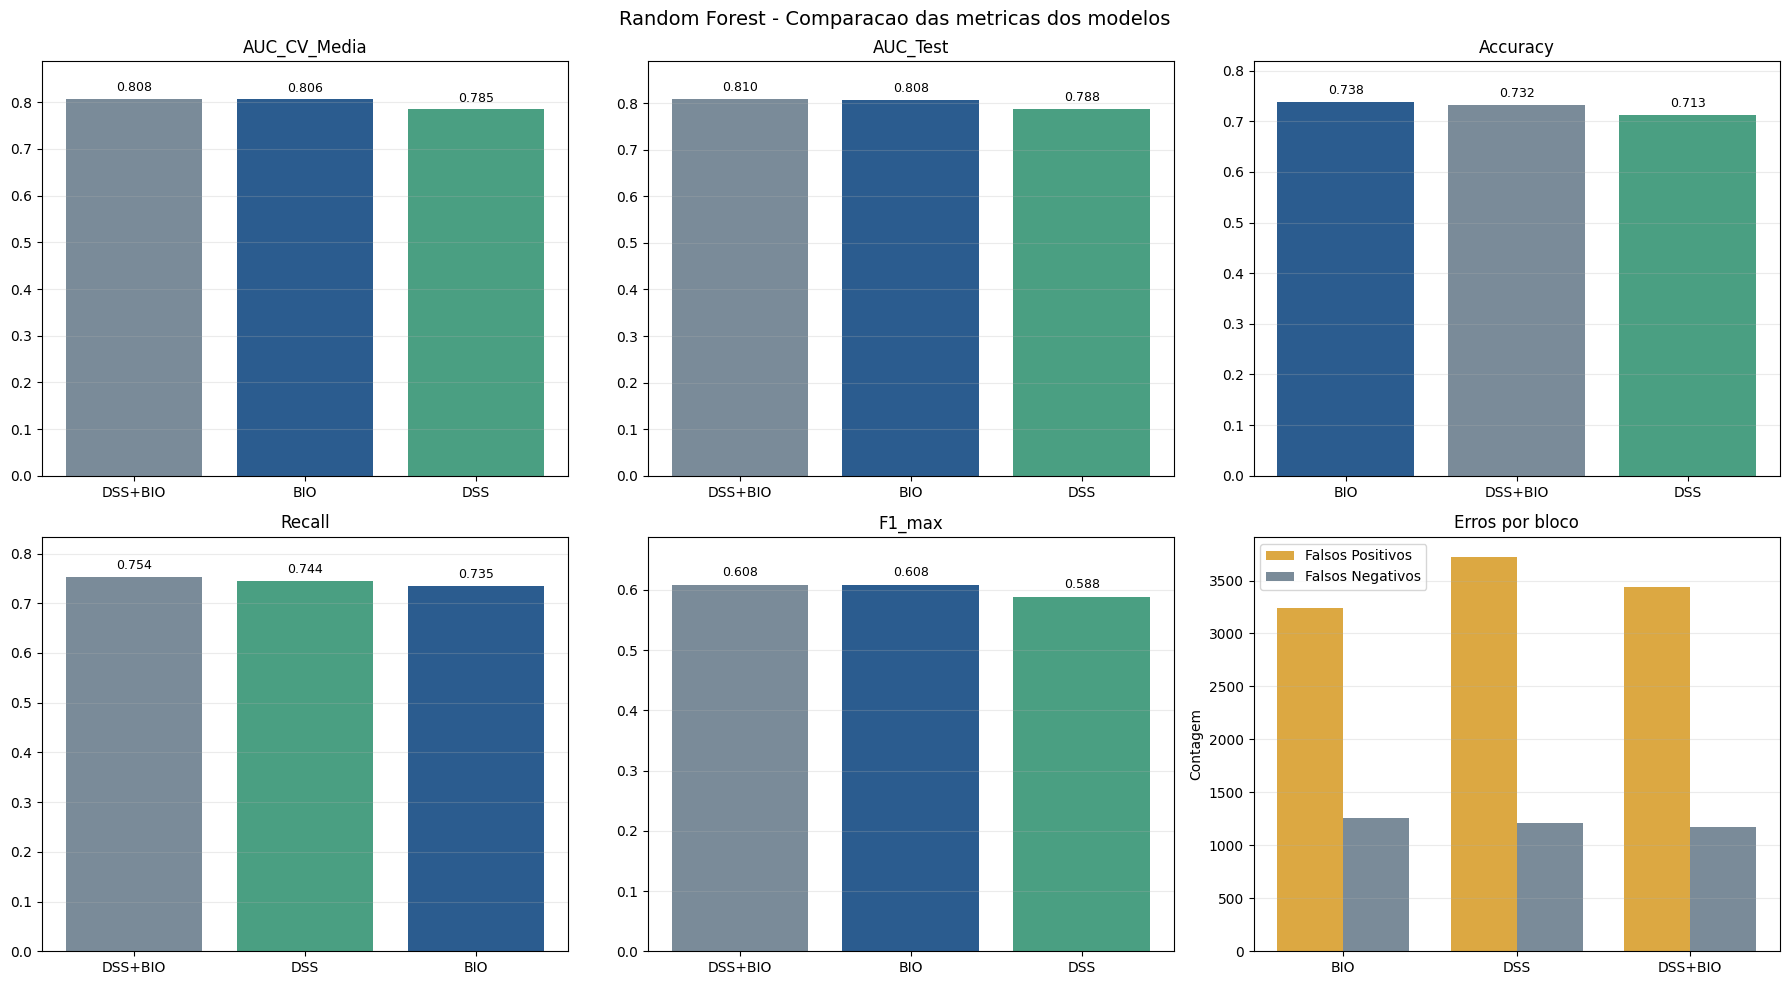

In [33]:
from pathlib import Path
import sys

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

palette = get_palette("categorical")
model_color_map = {
    "BIO":     palette[0],
    "DSS":     palette[1],
    "DSS+BIO": palette[2],
}

if "resultados_comparativos" not in globals():
    raise RuntimeError("Execute primeiro a celula que gera 'resultados_comparativos'.")

rf_plot = resultados_comparativos.copy()
metricas_rf = ["AUC_CV_Media", "AUC_Test", "Accuracy", "Recall", "F1_max"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metrica in enumerate(metricas_rf):
    ax = axes[i]
    dados = rf_plot[["Bloco", metrica]].sort_values(metrica, ascending=False)
    cores_metricas = [model_color_map.get(m, palette[3]) for m in dados["Bloco"]]
    bars = ax.bar(dados["Bloco"], dados[metrica], color=cores_metricas)
    ax.set_title(metrica)
    ax.set_ylim(0, min(1.05, float(dados[metrica].max()) + 0.08))
    ax.grid(axis="y", alpha=0.25)

    for bar, val in zip(bars, dados[metrica]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax_err = axes[5]
x = np.arange(len(rf_plot))
width = 0.38
ax_err.bar(x - width / 2, rf_plot["Falsos_Positivos"], width, label="Falsos Positivos", color=palette[3])
ax_err.bar(x + width / 2, rf_plot["Falsos_Negativos"], width, label="Falsos Negativos", color=palette[2])
ax_err.set_xticks(x)
ax_err.set_xticklabels(rf_plot["Bloco"])
ax_err.set_title("Erros por bloco")
ax_err.set_ylabel("Contagem")
ax_err.legend()
ax_err.grid(axis="y", alpha=0.25)

plt.suptitle("Random Forest - Comparacao das metricas dos modelos", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# --- Função de avaliação COMPLETA para salvar curvas de threshold ---
def avaliar_com_threshold_otimo(modelo, X_test, y_test):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    y_pred = (y_prob >= best_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "auc_test": roc_auc_score(y_test, y_prob),
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "threshold_f1": best_threshold,
        "f1_max": f1_scores[best_idx],
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdadeiro_positivos": tp,
        "verdadeiro_negativos": tn,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "cm": cm,
        # --- Adiciona as curvas completas ---
        "thresholds": thresholds,
        "precisions": precisions,
        "recalls": recalls,
        "f1_scores": f1_scores,
    }

# Recalcule as avaliações para popular as curvas
linhas_resultado = []
avaliacoes = {}
for bloco, familias in resultados_grid.items():
    avaliacoes[bloco] = {}
    for familia, artefatos in familias.items():
        met = avaliar_com_threshold_otimo(
            artefatos["best_model"],
            artefatos["X_test"],
            artefatos["y_test"],
        )
        avaliacoes[bloco][familia] = met
        linhas_resultado.append({
            "Bloco": bloco,
            "Modelo": familia,
            "AUC_CV_Media": artefatos["best_cv_auc"],
            "AUC_Test": met["auc_test"],
            "Accuracy": met["accuracy"],
            "Recall": met["recall"],
            "Threshold_F1": met["threshold_f1"],
            "F1_max": met["f1_max"],
            "Falsos_Positivos": met["falsos_positivos"],
            "Falsos_Negativos": met["falsos_negativos"],
            "Verdadeiro_Positivos": met["verdadeiro_positivos"],
            "Verdadeiro_Negativos": met["verdadeiro_negativos"],
        })
resultados_comparativos = pd.DataFrame(linhas_resultado).sort_values(["Bloco", "AUC_Test"], ascending=[True, False])
print("\nTabela comparativa final:")
display(resultados_comparativos)



Tabela comparativa final:


,Bloco,Modelo,AUC_CV_Media,AUC_Test,Accuracy,Recall,Threshold_F1,F1_max,Falsos_Positivos,Falsos_Negativos,Verdadeiro_Positivos,Verdadeiro_Negativos
0,BIO,Random Forest,0.806327,0.807689,0.738299,0.734767,0.524261,0.607619,3243,1258,3485,9213
1,DSS,Random Forest,0.784940,0.787530,0.712774,0.744044,0.516900,0.588265,3726,1214,3529,8730
2,DSS+BIO,Random Forest,0.807582,0.809821,0.731903,0.753532,0.504427,0.607875,3442,1169,3574,9014


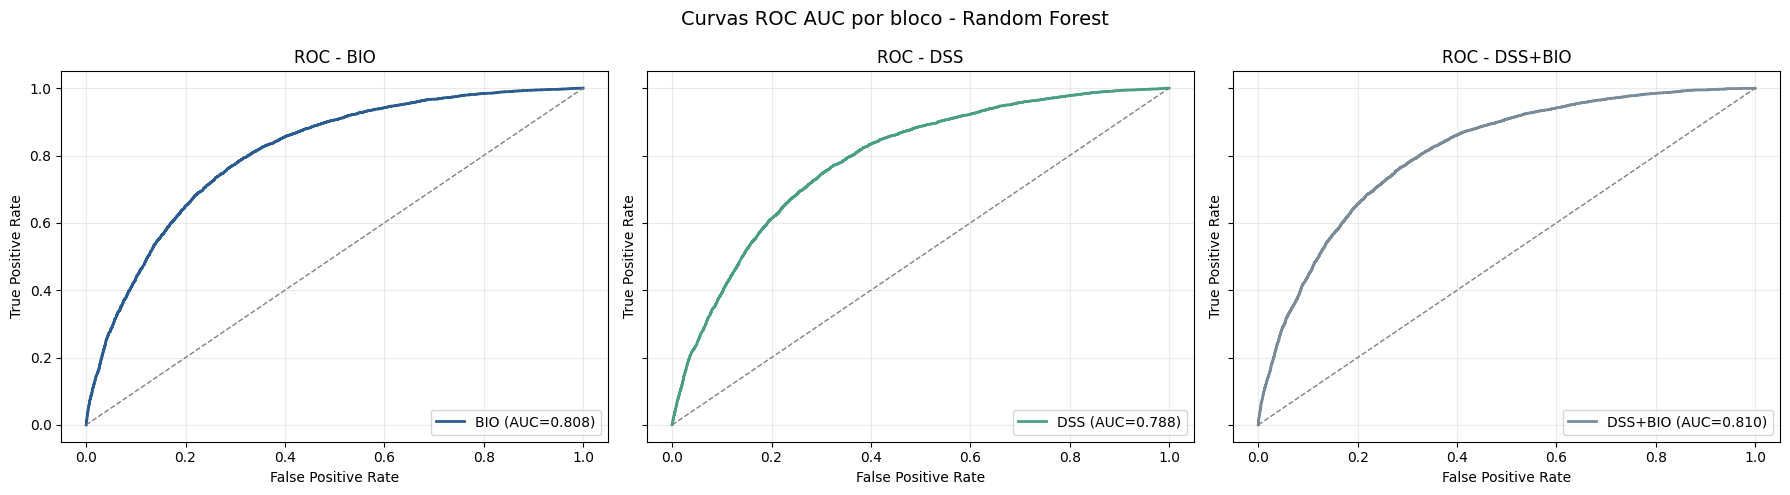

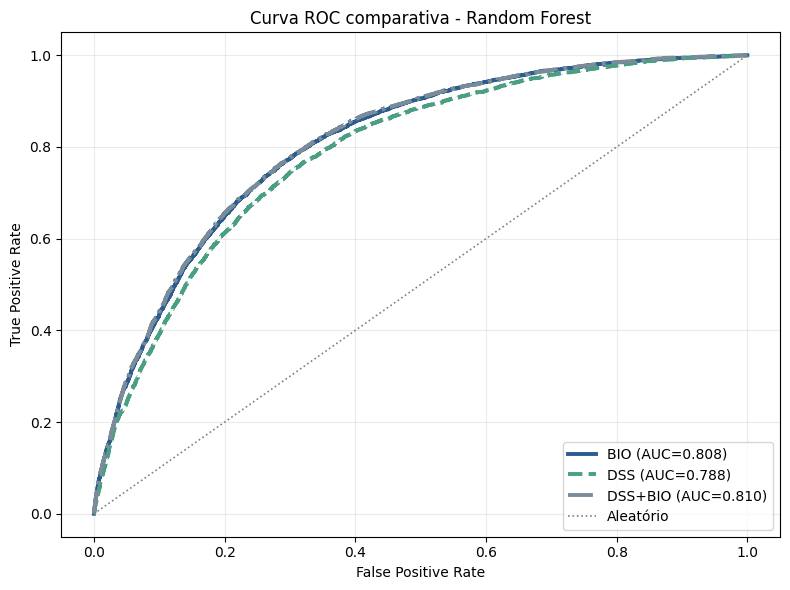

In [34]:
from sklearn.metrics import roc_curve
from pathlib import Path
import sys

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

palette = get_palette("categorical")
model_color_map = {
    "BIO":     palette[0],
    "DSS":     palette[1],
    "DSS+BIO": palette[2],
}

if "resultados_grid" not in globals() or "avaliacoes" not in globals():
    raise RuntimeError("Execute primeiro as celulas de treino e avaliacao dos modelos.")

blocos_ordem = ["BIO", "DSS", "DSS+BIO"]

# 1) Curvas ROC individuais
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for i, bloco in enumerate(blocos_ordem):
    y_true = resultados_grid[bloco]["Random Forest"]["y_test"]
    y_prob = avaliacoes[bloco]["Random Forest"]["y_prob"]
    auc_bloco = avaliacoes[bloco]["Random Forest"]["auc_test"]
    cor = model_color_map.get(bloco, palette[3])

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[i].plot(fpr, tpr, linewidth=2, color=cor, label=f"{bloco} (AUC={auc_bloco:.3f})")
    axes[i].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axes[i].set_title(f"ROC - {bloco}")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.25)

plt.suptitle("Curvas ROC AUC por bloco - Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

# 2) Curva ROC comparativa (3 modelos no mesmo eixo)
roc_style_map = {
    "BIO":     {"color": palette[0], "linestyle": "-",  "linewidth": 2.8},
    "DSS":     {"color": palette[1], "linestyle": "--", "linewidth": 2.8},
    "DSS+BIO": {"color": palette[2], "linestyle": "-.", "linewidth": 2.8},
}

fig, ax = plt.subplots(figsize=(8, 6))
for bloco in blocos_ordem:
    y_true = resultados_grid[bloco]["Random Forest"]["y_test"]
    y_prob = avaliacoes[bloco]["Random Forest"]["y_prob"]
    auc_bloco = avaliacoes[bloco]["Random Forest"]["auc_test"]
    style = roc_style_map.get(bloco, {"color": palette[3], "linestyle": "-", "linewidth": 2.5})

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{bloco} (AUC={auc_bloco:.3f})", **style)

ax.plot([0, 1], [0, 1], linestyle=":", color="gray", linewidth=1.2, label="Aleatório")
ax.set_title("Curva ROC comparativa - Random Forest")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Curvas ROC AUC (individuais e comparativa)

Visualizacao individual de cada bloco (BIO, DSS, DSS+BIO) e comparacao conjunta das curvas ROC.

## Graficos das metricas dos modelos

Comparacao visual das principais metricas (AUC, Accuracy, Recall, F1) e erros (FP/FN) entre os blocos BIO, DSS e DSS+BIO.

## Feature Importance



Top importâncias - Random Forest - BIO


,feature,importance
18,imc_x_idade,0.424169
0,idade_c,0.279315
14,imc,0.144536
6,sexo_x_idade,0.070210
15,atividade_x_idade,0.028408
8,raca_Parda_x_idade,0.014759
17,alcool_x_idade,0.014736
1,sexo_feminino,0.009211
16,tabagismo_x_idade,0.004486
7,raca_Preta_x_idade,0.003058


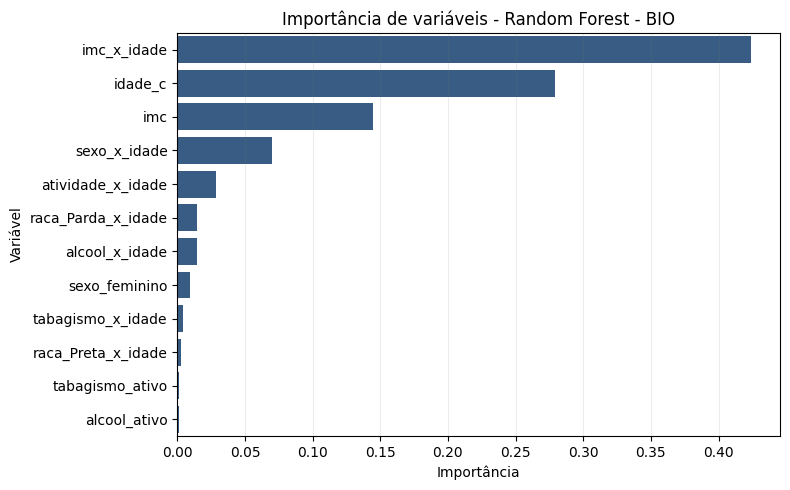


Top importâncias - Random Forest - DSS


,feature,importance
16,renda_x_idade,0.265047
0,idade_c,0.255261
18,situacao_x_idade,0.121215
15,esc_x_idade,0.116914
6,sexo_x_idade,0.077498
8,raca_Parda_x_idade,0.050118
11,escolaridade_ord,0.028214
19,indice_socioeconomico_x_idade,0.027482
12,renda_per_capita_log,0.016525
1,sexo_feminino,0.016212


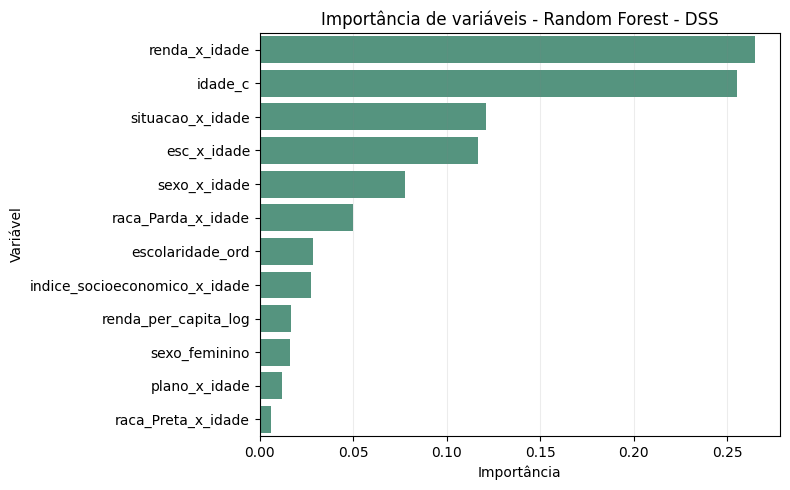


Top importâncias - Random Forest - DSS+BIO


,feature,importance
18,imc_x_idade,0.384323
0,idade_c,0.207896
24,renda_x_idade,0.124681
14,imc,0.118867
23,esc_x_idade,0.028073
6,sexo_x_idade,0.024728
28,renda_x_imc,0.022226
26,situacao_x_idade,0.019372
27,indice_socioeconomico_x_idade,0.015824
20,renda_per_capita_log,0.011706


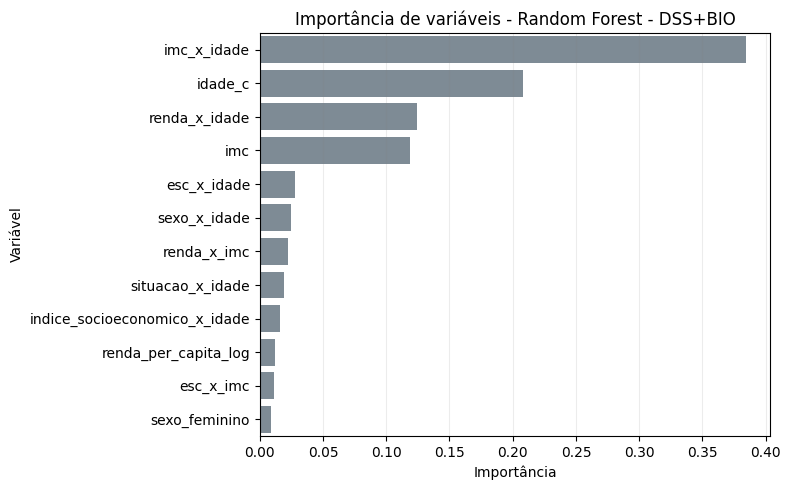

In [36]:
from pathlib import Path
import sys

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

_palette = get_palette("categorical")
_color_map = {"BIO": _palette[0], "DSS": _palette[1], "DSS+BIO": _palette[2]}


def tabela_importancia(modelo_pipeline, nomes_features, top_n=15):
    importancias = modelo_pipeline.named_steps["model"].feature_importances_
    tab = pd.DataFrame({
        "feature": nomes_features,
        "importance": importancias,
    }).sort_values("importance", ascending=False)
    return tab.head(top_n)


for bloco, familias in resultados_grid.items():
    for familia, artefatos in familias.items():
        top_imp = tabela_importancia(
            artefatos["best_model"],
            artefatos["features"],
            top_n=12,
        )

        print(f"\nTop importâncias - {familia} - {bloco}")
        display(top_imp)

        plt.figure(figsize=(8, 5))
        sns.barplot(data=top_imp, x="importance", y="feature", color=_color_map.get(bloco, _palette[3]))
        plt.title(f"Importância de variáveis - {familia} - {bloco}")
        plt.xlabel("Importância")
        plt.ylabel("Variável")
        plt.gca().grid(axis='x', color='gray', alpha=0.15, linewidth=0.8)
        plt.tight_layout()
        plt.show()

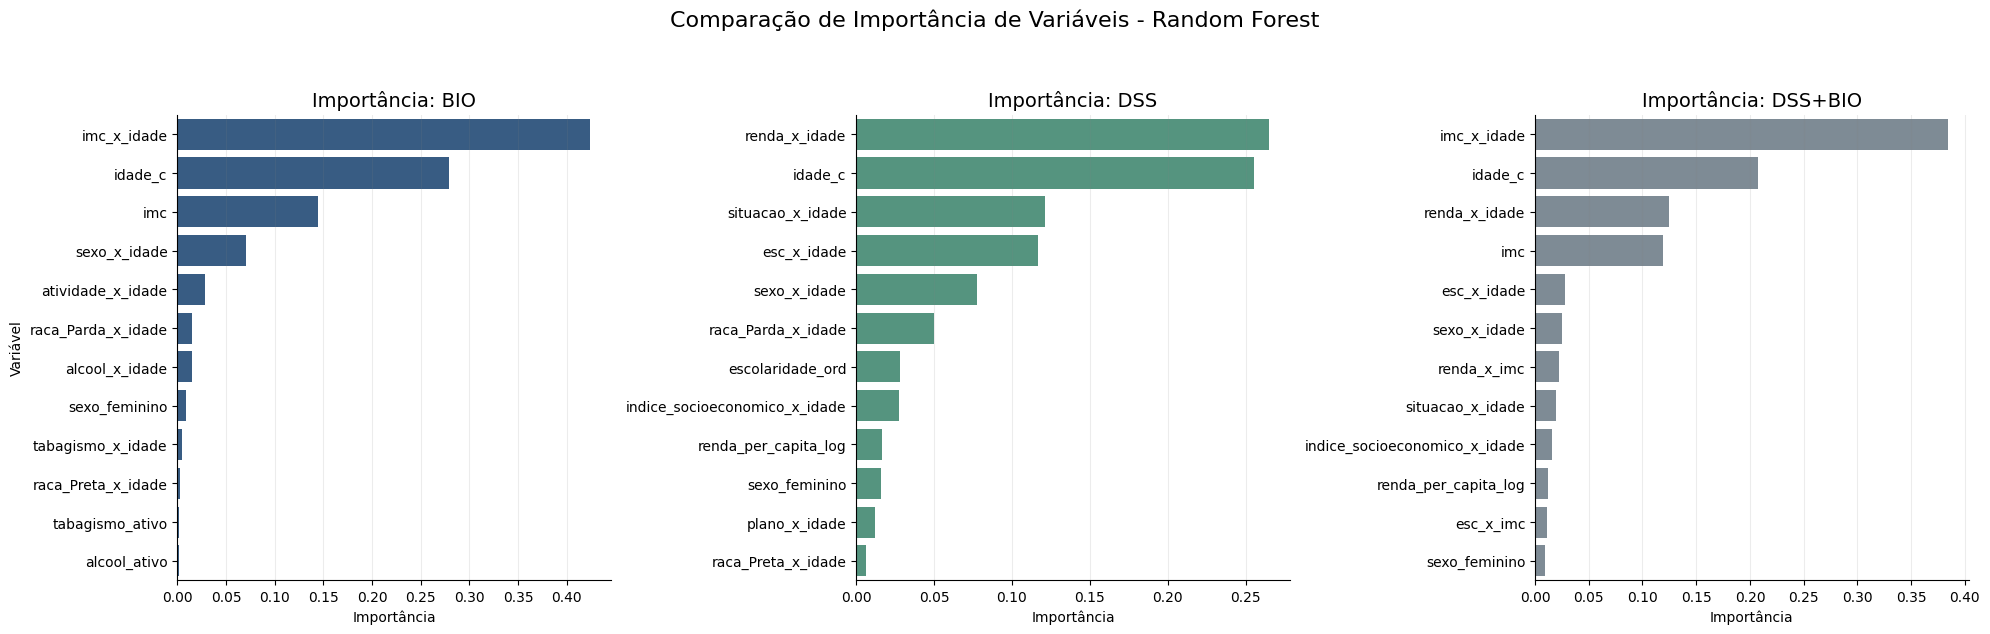

In [37]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

palette = get_palette("categorical")
model_color_map = {
    "BIO":     palette[0],
    "DSS":     palette[1],
    "DSS+BIO": palette[2],
}

blocos_ordem = ["BIO", "DSS", "DSS+BIO"]
familia_alvo = "Random Forest"

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=False)

for i, bloco in enumerate(blocos_ordem):
    if bloco in resultados_grid and familia_alvo in resultados_grid[bloco]:
        artefatos = resultados_grid[bloco][familia_alvo]

        top_imp = tabela_importancia(
            artefatos["best_model"],
            artefatos["features"],
            top_n=12
        )

        cor = model_color_map.get(bloco, palette[3])
        sns.barplot(data=top_imp, x="importance", y="feature", ax=axes[i], color=cor)

        axes[i].set_title(f"Importância: {bloco}", fontsize=14)
        axes[i].set_xlabel("Importância")
        axes[i].set_ylabel("Variável" if i == 0 else "")
        axes[i].grid(axis='x', color='gray', alpha=0.15, linewidth=0.8)

        sns.despine(ax=axes[i])

plt.suptitle(f"Comparação de Importância de Variáveis - {familia_alvo}", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

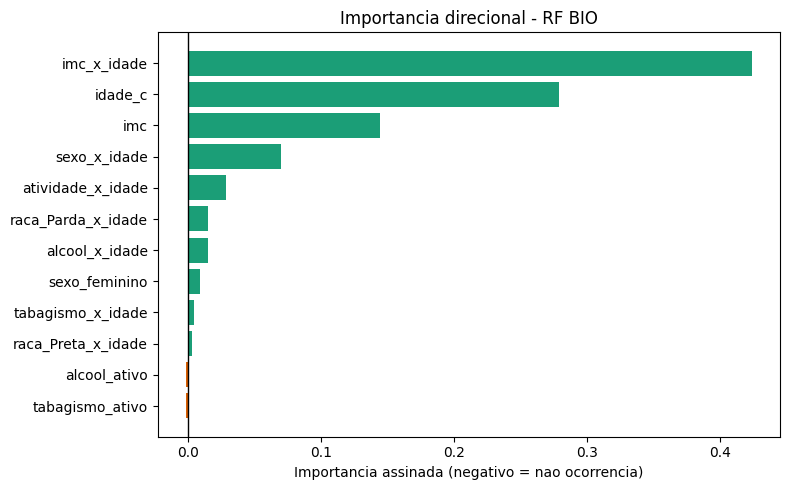

,feature,importancia_assinada,sentido
0,tabagismo_ativo,-0.001562,Nao ocorrencia
1,alcool_ativo,-0.001503,Nao ocorrencia
2,raca_Preta_x_idade,0.003058,Ocorrencia
3,tabagismo_x_idade,0.004486,Ocorrencia
4,sexo_feminino,0.009211,Ocorrencia
5,alcool_x_idade,0.014736,Ocorrencia
6,raca_Parda_x_idade,0.014759,Ocorrencia
7,atividade_x_idade,0.028408,Ocorrencia
8,sexo_x_idade,0.070210,Ocorrencia
9,imc,0.144536,Ocorrencia


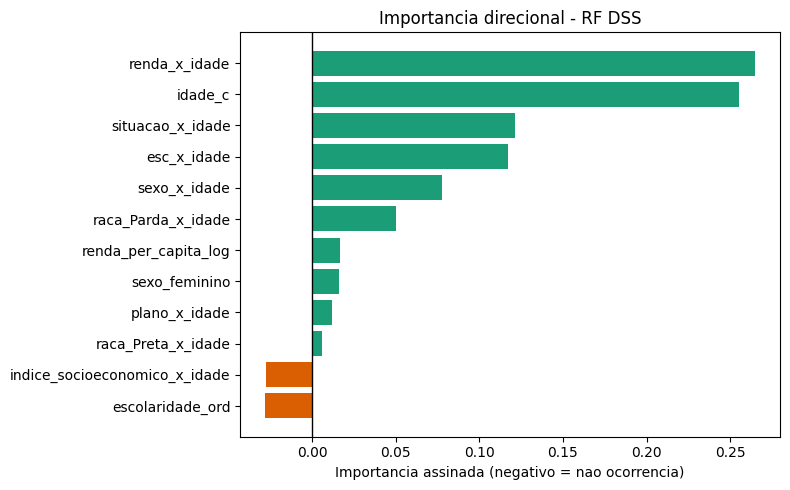

,feature,importancia_assinada,sentido
0,escolaridade_ord,-0.028214,Nao ocorrencia
1,indice_socioeconomico_x_idade,-0.027482,Nao ocorrencia
2,raca_Preta_x_idade,0.006040,Ocorrencia
3,plano_x_idade,0.012120,Ocorrencia
4,sexo_feminino,0.016212,Ocorrencia
5,renda_per_capita_log,0.016525,Ocorrencia
6,raca_Parda_x_idade,0.050118,Ocorrencia
7,sexo_x_idade,0.077498,Ocorrencia
8,esc_x_idade,0.116914,Ocorrencia
9,situacao_x_idade,0.121215,Ocorrencia


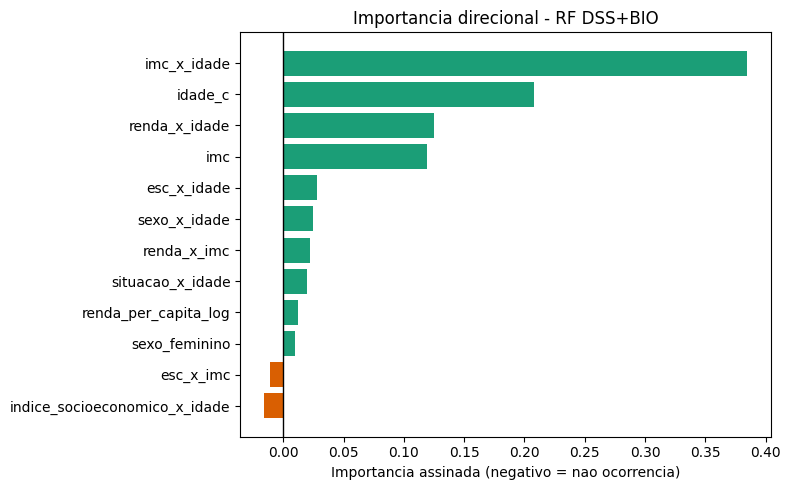

,feature,importancia_assinada,sentido
0,indice_socioeconomico_x_idade,-0.015824,Nao ocorrencia
1,esc_x_imc,-0.011311,Nao ocorrencia
2,sexo_feminino,0.009210,Ocorrencia
3,renda_per_capita_log,0.011706,Ocorrencia
4,situacao_x_idade,0.019372,Ocorrencia
5,renda_x_imc,0.022226,Ocorrencia
6,sexo_x_idade,0.024728,Ocorrencia
7,esc_x_idade,0.028073,Ocorrencia
8,imc,0.118867,Ocorrencia
9,renda_x_idade,0.124681,Ocorrencia


In [23]:
if "resultados_grid" not in globals():
    raise RuntimeError("Execute primeiro a celula de treinamento dos modelos.")

for bloco, familias in resultados_grid.items():
    artefatos = familias["Random Forest"]
    modelo_rf = artefatos["best_model"].named_steps["model"]
    X_test = artefatos["X_test"].copy()
    y_test = artefatos["y_test"].copy()

    imp = pd.Series(modelo_rf.feature_importances_, index=artefatos["features"], name="importance")

    # Sinal pela correlacao feature vs desfecho (teste)
    sinais = []
    for col in imp.index:
        par = pd.concat([pd.to_numeric(X_test[col], errors="coerce"), pd.to_numeric(y_test, errors="coerce")], axis=1).dropna()
        if par.empty or par.iloc[:, 0].nunique() <= 1:
            sinais.append(0.0)
        else:
            sinais.append(np.sign(par.iloc[:, 0].corr(par.iloc[:, 1])))

    sinais = pd.Series(sinais, index=imp.index, name="sinal")
    imp_dir = (imp * sinais).sort_values()
    top_dir = imp_dir.reindex(imp_dir.abs().sort_values(ascending=False).head(12).index).sort_values()

    cores = np.where(top_dir >= 0, "#1b9e77", "#d95f02")

    plt.figure(figsize=(8, 5))
    plt.barh(top_dir.index, top_dir.values, color=cores)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Importancia direcional - RF {bloco}")
    plt.xlabel("Importancia assinada (negativo = nao ocorrencia)")
    plt.tight_layout()
    plt.show()

    display(
        pd.DataFrame({
            "feature": top_dir.index,
            "importancia_assinada": top_dir.values,
            "sentido": np.where(top_dir.values >= 0, "Ocorrencia", "Nao ocorrencia"),
        }).reset_index(drop=True)
    )

## Importancia direcional das features

No Random Forest, a importancia padrao e sempre positiva. Para capturar o sentido da associacao, usamos o sinal da correlacao no conjunto de teste: valores negativos indicam maior associacao com a nao ocorrencia do desfecho.

## Calibração das probabilidades

Curva de calibração e Brier Score para avaliar a confiabilidade das probabilidades previstas em cada bloco do Random Forest.

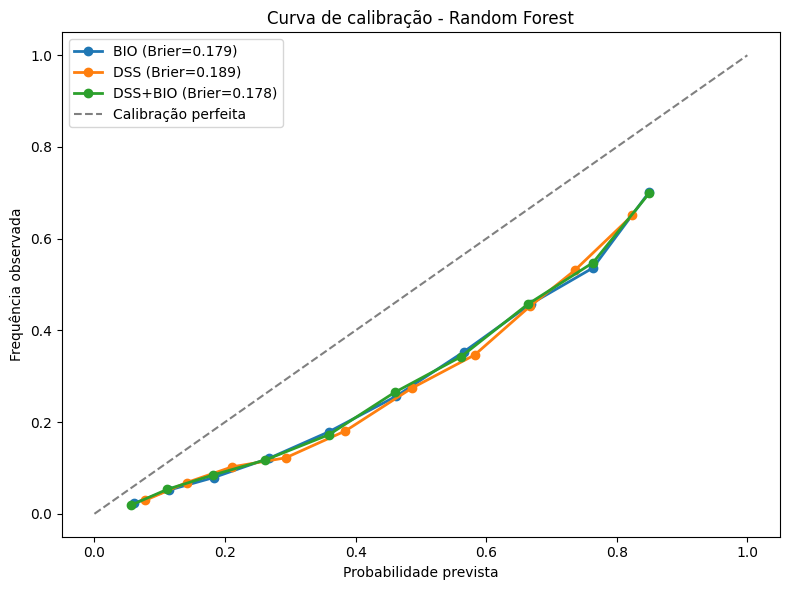

,Bloco,Brier_Score,AUC_Test
2,DSS+BIO,0.177745,0.809821
0,BIO,0.179215,0.807689
1,DSS,0.189145,0.787530


In [24]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

calibracao_rf = []

plt.figure(figsize=(8, 6))

for bloco, familias in resultados_grid.items():
    artefatos = familias["Random Forest"]
    y_true = artefatos["y_test"]
    y_prob = avaliacoes[bloco]["Random Forest"]["y_prob"]

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10,
        strategy="quantile",
    )
    brier = brier_score_loss(y_true, y_prob)

    calibracao_rf.append({
        "Bloco": bloco,
        "Brier_Score": brier,
        "AUC_Test": avaliacoes[bloco]["Random Forest"]["auc_test"],
    })

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2,
        label=f"{bloco} (Brier={brier:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.title("Curva de calibração - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(calibracao_rf).sort_values("Brier_Score"))

A incorporação dos Determinantes Sociais da Saúde não apenas contribui para a performance discriminativa dos modelos, mas também melhora a confiabilidade das probabilidades preditas, como evidenciado pela redução do Brier Score e maior proximidade com a linha de calibração perfeita.

Apesar do Random forest correr o risco de ser overconfident, ele se mostra bem calibrado, proximo a linha de calibragem perfeita.

## 2. Utilidade Clínica e Equidade

Esta seção adiciona Decision Curve Analysis (DCA) para benefício líquido em diferentes limiares e métricas de equidade (Paridade Demográfica e Igualdade de Oportunidades) por raça, sexo e escolaridade.

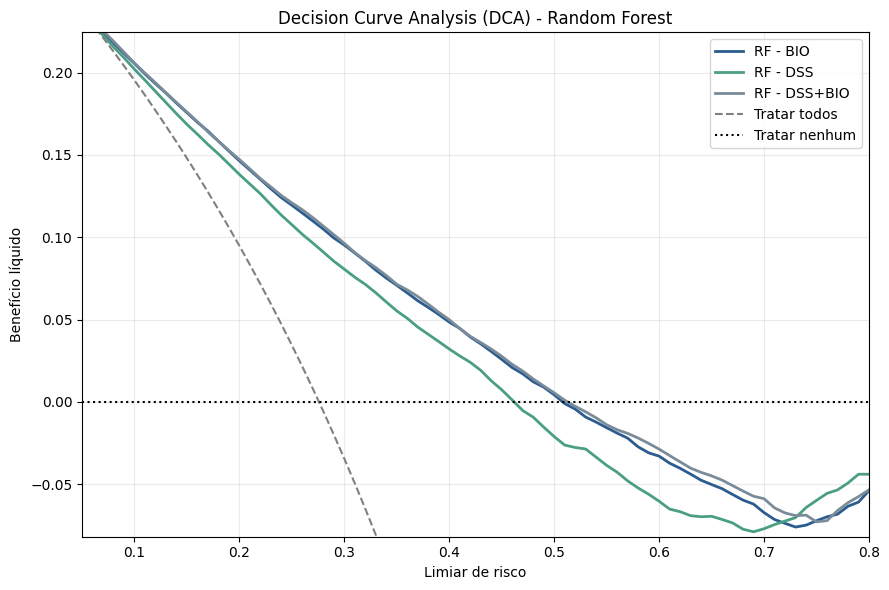


Equidade - Random Forest - BIO
Threshold usado (F1 ótimo): 0.5243

Grupo: Raca


,grupo,n,taxa_pred_positiva,tpr
0,Amarela,116,0.353448,0.710526
1,Branca/Outras,6373,0.444532,0.780926
2,Indigena,132,0.386364,0.720930
3,Parda,8712,0.350436,0.699550
4,Preta,1866,0.401929,0.726524


Paridade Demográfica (gap): 0.0941
Igualdade de Oportunidades (gap): 0.0814

Grupo: Sexo


,grupo,n,taxa_pred_positiva,tpr
0,Feminino,9074,0.455698,0.775410
1,Masculino,8125,0.319138,0.672872


Paridade Demográfica (gap): 0.1366
Igualdade de Oportunidades (gap): 0.1025

Grupo: Escolaridade


...

Paridade Demográfica (gap): 0.0924
Igualdade de Oportunidades (gap): 0.0806

Grupo: Sexo


,grupo,n,taxa_pred_positiva,tpr
0,Feminino,9074,0.465836,0.785190
1,Masculino,8125,0.343262,0.705319


Paridade Demográfica (gap): 0.1226
Igualdade de Oportunidades (gap): 0.0799

Grupo: Escolaridade


,grupo,n,taxa_pred_positiva,tpr
0,Analfabeto,999,0.743744,0.889625
1,Fund.,6677,0.545754,0.809762
2,Medio,5299,0.270051,0.630639
3,Nao informado,1430,0.197902,0.686916
4,Pos-grad,766,0.360313,0.660714
5,Superior,2028,0.315089,0.673378


Paridade Demográfica (gap): 0.5458
Igualdade de Oportunidades (gap): 0.2590


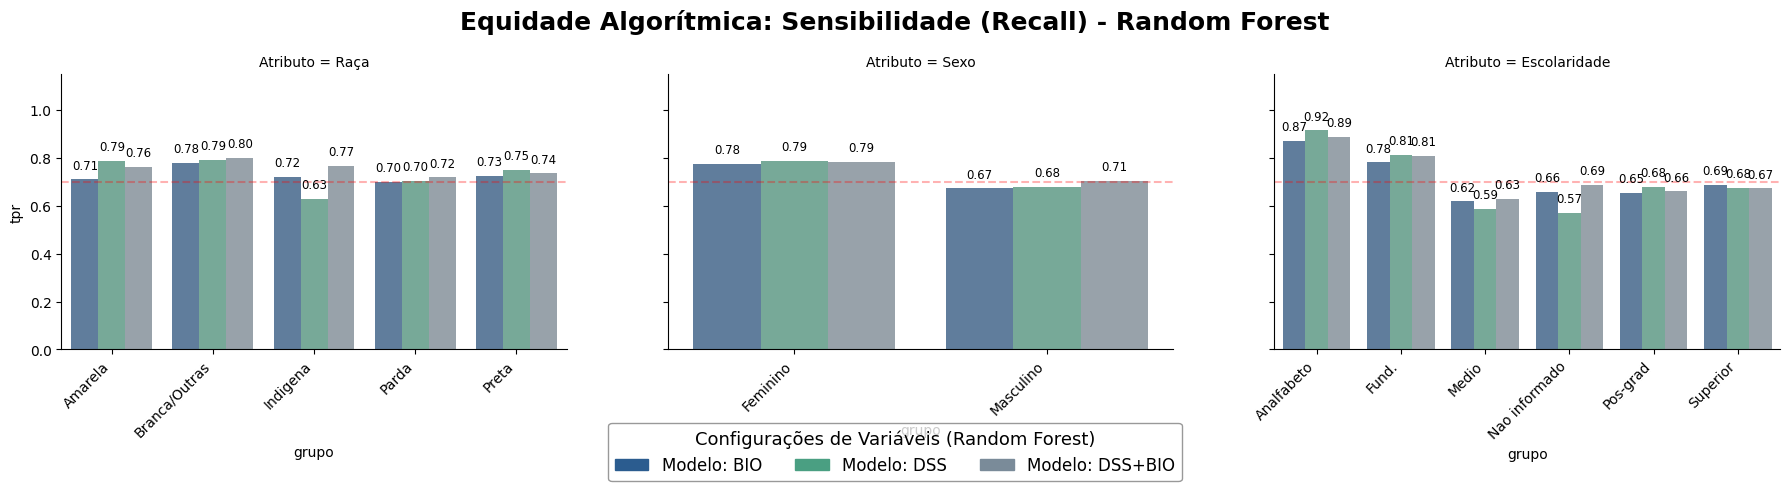

In [42]:
from pathlib import Path
import sys
import matplotlib.patches as mpatches

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

def _dca_manual_df(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    prevalence = y_true.mean()
    rows = []

    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            continue
        y_hat = (y_prob >= pt).astype(int)
        tp = ((y_hat == 1) & (y_true == 1)).sum()
        fp = ((y_hat == 1) & (y_true == 0)).sum()

        net_benefit_model = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefit_all = prevalence - (1 - prevalence) * (pt / (1 - pt))

        rows.append({
            "threshold": pt,
            "net_benefit_model": net_benefit_model,
            "net_benefit_all": net_benefit_all,
            "net_benefit_none": 0.0,
        })

    return pd.DataFrame(rows)

def _fairness_by_group(y_true, y_prob, threshold, group_series, min_n=30):
    y_true = pd.Series(np.asarray(y_true).astype(int)).reset_index(drop=True)
    y_pred = pd.Series((np.asarray(y_prob) >= threshold).astype(int)).reset_index(drop=True)
    group_series = pd.Series(group_series).reset_index(drop=True)
    group_series = group_series.astype("string").fillna("Nao informado")

    rows = []
    for grp in sorted(group_series.unique()):
        mask = group_series == grp
        n_grp = int(mask.sum())
        if n_grp < min_n:
            continue

        yt = y_true[mask]
        yp = y_pred[mask]
        positives = int((yt == 1).sum())

        pred_pos_rate = float((yp == 1).mean())
        tpr = np.nan
        if positives > 0:
            tpr = float(((yp == 1) & (yt == 1)).sum() / positives)

        rows.append({
            "grupo": grp,
            "n": n_grp,
            "taxa_pred_positiva": pred_pos_rate,
            "tpr": tpr,
        })

    tab = pd.DataFrame(rows)
    if tab.empty:
        return tab, {"dp_diff": np.nan, "eopp_diff": np.nan}

    dp_diff = float(tab["taxa_pred_positiva"].max() - tab["taxa_pred_positiva"].min())
    tpr_valid = tab["tpr"].dropna()
    eopp_diff = float(tpr_valid.max() - tpr_valid.min()) if not tpr_valid.empty else np.nan

    return tab.sort_values("grupo"), {"dp_diff": dp_diff, "eopp_diff": eopp_diff}

def _grupo_racial(X):
    cols = ["raca_Preta", "raca_Parda", "raca_Amarela", "raca_Indigena"]
    if not all(c in X.columns for c in cols):
        return pd.Series(["Nao disponivel"] * len(X), index=X.index)

    grp = np.select(
        [
            X["raca_Preta"] == 1,
            X["raca_Parda"] == 1,
            X["raca_Amarela"] == 1,
            X["raca_Indigena"] == 1,
        ],
        ["Preta", "Parda", "Amarela", "Indigena"],
        default="Branca/Outras",
    )
    return pd.Series(grp, index=X.index)

palette = get_palette("categorical")
model_color_map = {
    "BIO":     palette[0],
    "DSS":     palette[1],
    "DSS+BIO": palette[2],
}

# Faixa de limiar com maior utilidade clínica visual
thresholds = np.linspace(0.05, 0.80, 76)
dca_tables = {}
model_nb_vals = []

plt.figure(figsize=(9, 6))
for bloco, familias in resultados_grid.items():
    artefatos = familias["Random Forest"]
    y_true = artefatos["y_test"]
    y_prob = avaliacoes[bloco]["Random Forest"]["y_prob"]
    dca_df = _dca_manual_df(y_true, y_prob, thresholds)
    dca_tables[bloco] = dca_df
    model_nb_vals.append(dca_df["net_benefit_model"].to_numpy())
    plt.plot(dca_df["threshold"], dca_df["net_benefit_model"], linewidth=2,
             color=model_color_map.get(bloco, palette[3]), label=f"RF - {bloco}")

if len(dca_tables) > 0:
    ref_df = next(iter(dca_tables.values()))
    plt.plot(ref_df["threshold"], ref_df["net_benefit_all"], linestyle="--", color="gray", label="Tratar todos")
    plt.plot(ref_df["threshold"], ref_df["net_benefit_none"], linestyle=":", color="black", label="Tratar nenhum")

plt.xlim(float(thresholds.min()), float(thresholds.max()))
if model_nb_vals:
    nb = np.concatenate(model_nb_vals)
    y_min = min(-0.02, float(np.nanpercentile(nb, 5) - 0.01))
    y_max = max(0.02, float(np.nanpercentile(nb, 95) + 0.01))
    if y_min < y_max:
        plt.ylim(y_min, y_max)

plt.xlabel("Limiar de risco")
plt.ylabel("Benefício líquido")
plt.title("Decision Curve Analysis (DCA) - Random Forest")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Mapear escolaridade ordinal para rótulos legíveis
escolaridade_labels = {0.0: "Analfabeto", 1.0: "Fund.", 2.0: "Medio", 3.0: "Superior", 4.0: "Pos-grad"}

for bloco, familias in resultados_grid.items():
    artefatos = familias["Random Forest"]
    X_test = artefatos["X_test"]
    y_true = artefatos["y_test"]
    y_prob = avaliacoes[bloco]["Random Forest"]["y_prob"]
    threshold = avaliacoes[bloco]["Random Forest"]["threshold_f1"]

    print(f"\n{'='*80}")
    print(f"Equidade - Random Forest - {bloco}")
    print(f"Threshold usado (F1 ótimo): {threshold:.4f}")

    esc_serie = df.loc[X_test.index, "escolaridade_ord"].map(escolaridade_labels).fillna("Nao informado")

    grupos = {
        "Raca": _grupo_racial(X_test),
        "Sexo": X_test["sexo_feminino"].map({1: "Feminino", 0: "Masculino"}) if "sexo_feminino" in X_test.columns else pd.Series(["Nao disponivel"] * len(X_test), index=X_test.index),
        "Escolaridade": esc_serie,
    }

    for nome_grupo, serie_grupo in grupos.items():
        tab, gaps = _fairness_by_group(y_true, y_prob, threshold, serie_grupo)
        print(f"\nGrupo: {nome_grupo}")
        if tab.empty:
            print("Amostra insuficiente para calcular métricas de equidade.")
            continue
        display(tab)
        print(f"Paridade Demográfica (gap): {gaps['dp_diff']:.4f}")
        if np.isnan(gaps["eopp_diff"]):
            print("Igualdade de Oportunidades (gap): NA")
        else:
            print(f"Igualdade de Oportunidades (gap): {gaps['eopp_diff']:.4f}")

# 1. Consolidar os dados de equidade de todos os blocos
rf_fairness_data = []

for bloco in ["BIO", "DSS", "DSS+BIO"]:
    if bloco in resultados_grid:
        artefatos = resultados_grid[bloco]["Random Forest"]
        X_test = artefatos["X_test"]
        y_true = artefatos["y_test"]
        y_prob = avaliacoes[bloco]["Random Forest"]["y_prob"]
        threshold = avaliacoes[bloco]["Random Forest"]["threshold_f1"]

        esc_serie = df.loc[X_test.index, "escolaridade_ord"].map(escolaridade_labels).fillna("Nao informado")
        grupos = {
            "Raça": _grupo_racial(X_test),
            "Sexo": X_test["sexo_feminino"].map({1: "Feminino", 0: "Masculino"}) if "sexo_feminino" in X_test.columns else pd.Series(["N/A"] * len(X_test), index=X_test.index),
            "Escolaridade": esc_serie,
        }

        for nome_grupo, serie_grupo in grupos.items():
            tab, _ = _fairness_by_group(y_true, y_prob, threshold, serie_grupo)
            if not tab.empty:
                tab["Bloco"] = bloco
                tab["Atributo"] = nome_grupo
                rf_fairness_data.append(tab)

df_rf_fairness = pd.concat(rf_fairness_data, ignore_index=True)

# 2. Paleta do projeto (uma cor por modelo)
paleta_cores = [palette[0], palette[1], palette[2]]
cores_map = {"BIO": palette[0], "DSS": palette[1], "DSS+BIO": palette[2]}

# 3. Plotagem com FacetGrid
g = sns.catplot(
    data=df_rf_fairness,
    kind="bar",
    x="grupo",
    y="tpr",
    hue="Bloco",
    col="Atributo",
    col_wrap=3,
    palette=paleta_cores,
    alpha=0.8,
    height=5,
    aspect=1.2,
    sharex=False,
    legend=False
)

# 4. Legenda manual
legenda_manual = [
    mpatches.Patch(color=cores_map["BIO"], label='Modelo: BIO'),
    mpatches.Patch(color=cores_map["DSS"], label='Modelo: DSS'),
    mpatches.Patch(color=cores_map["DSS+BIO"], label='Modelo: DSS+BIO')
]

g.fig.legend(handles=legenda_manual, loc='lower center', ncol=3, fontsize=12,
             title="Configurações de Variáveis (Random Forest)", title_fontsize=13,
             frameon=True, edgecolor='gray', bbox_to_anchor=(0.5, 0.02))

# 5. Ajustes nos subplots
for ax in g.axes.flat:
    ax.axhline(0.70, color='red', linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1.15)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2., h),
                        ha='center', va='center', xytext=(0, 10),
                        textcoords='offset points', fontsize=8.5)

plt.subplots_adjust(top=0.85, bottom=0.30, hspace=0.8, wspace=0.2)
g.fig.suptitle('Equidade Algorítmica: Sensibilidade (Recall) - Random Forest',
               fontsize=18, fontweight='bold')

plt.show()


## 4. Interpretabilidade Clínica Avançada

### SHAP Values

SHAP (SHapley Additive exPlanations) decompõe cada predição em contribuições individuais de cada variável. Ao contrário da importância global do Random Forest (baseada em impureza média), o SHAP permite:
- **Interpretação local:** quanto cada variável contribuiu para *aquele* paciente específico.
- **Interpretação global:** média do valor absoluto dos SHAP — mais honesta que o feature importance padrão.

Para o Random Forest usamos o `TreeExplainer`, que é exato e eficiente.

### Razão de Prevalência (RP)

Em estudos transversais com prevalência alta (>10%), a Odds Ratio **superestima** a força de associação. A **Razão de Prevalência** (RP), estimada via regressão de Poisson modificada com variância robusta (Zou, 2004 – *American Journal of Epidemiology*), é a medida mais indicada para a PNS 2019.


d:\Workspace\TCCII\tcc_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



SHAP – Random Forest – BIO


<Figure size 800x500 with 0 Axes>

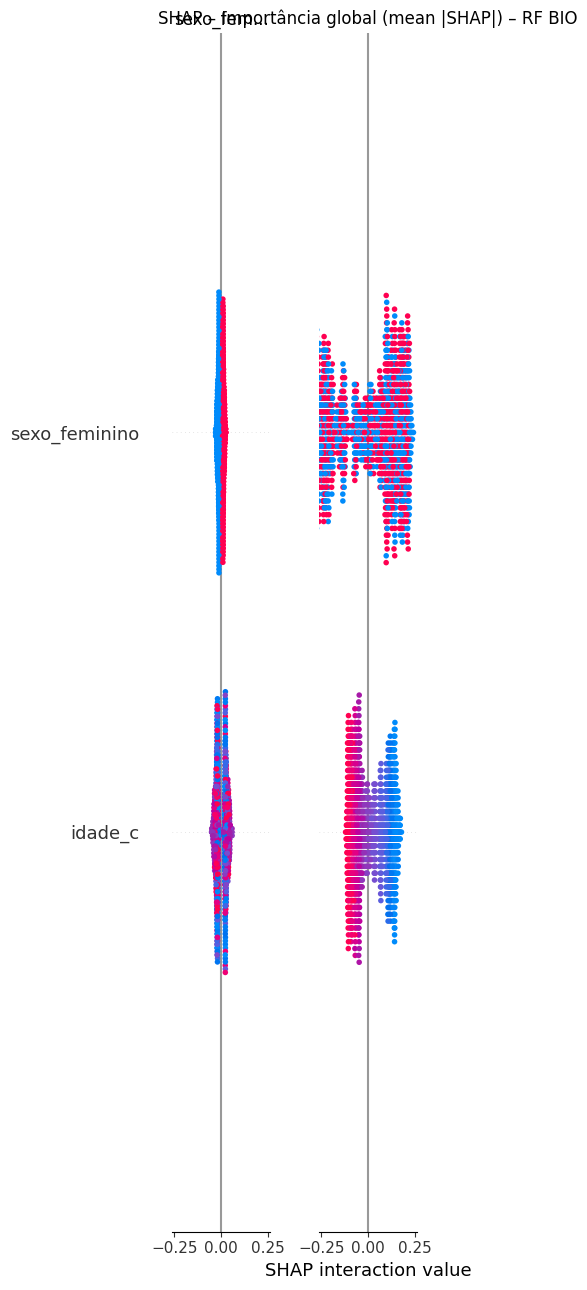

<Figure size 900x600 with 0 Axes>

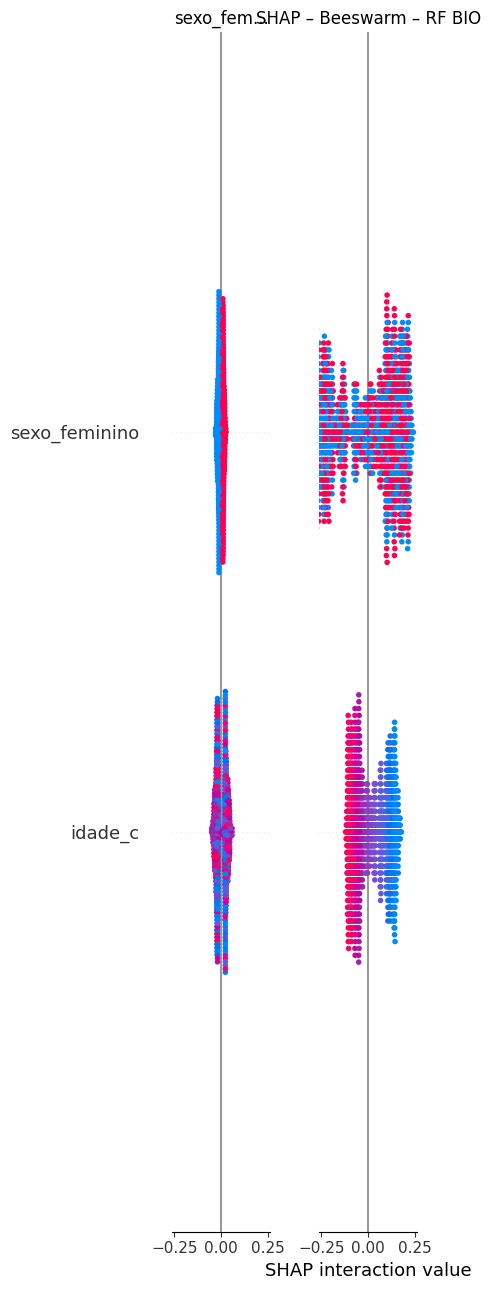


SHAP – Random Forest – DSS


<Figure size 800x500 with 0 Axes>

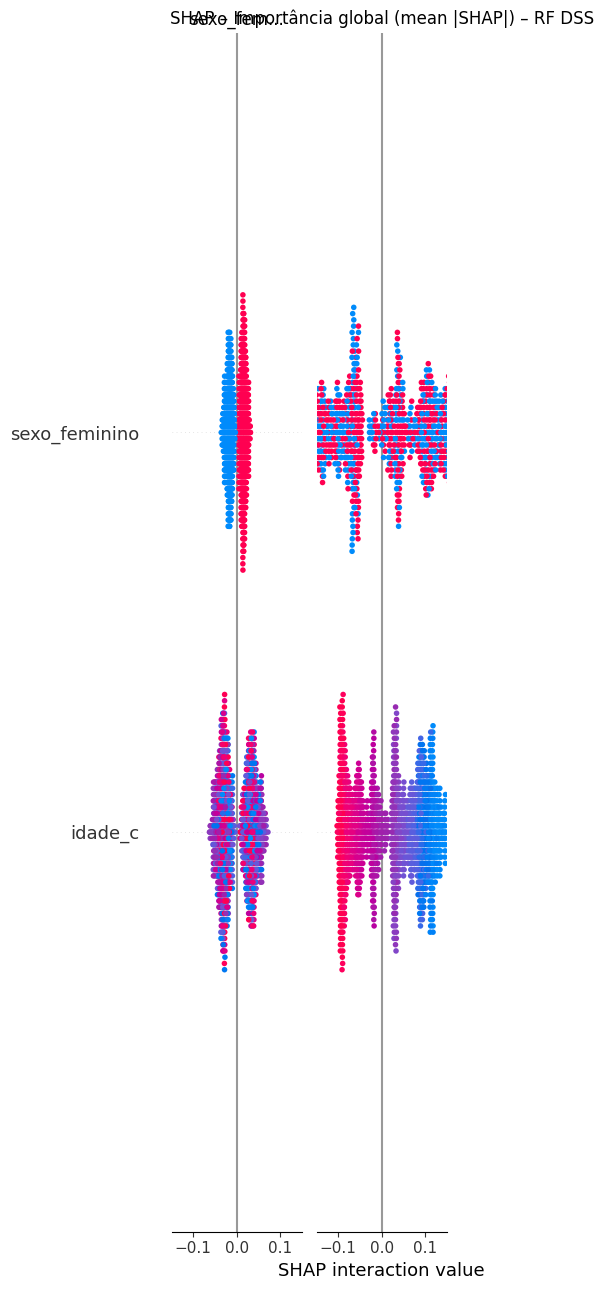

<Figure size 900x600 with 0 Axes>

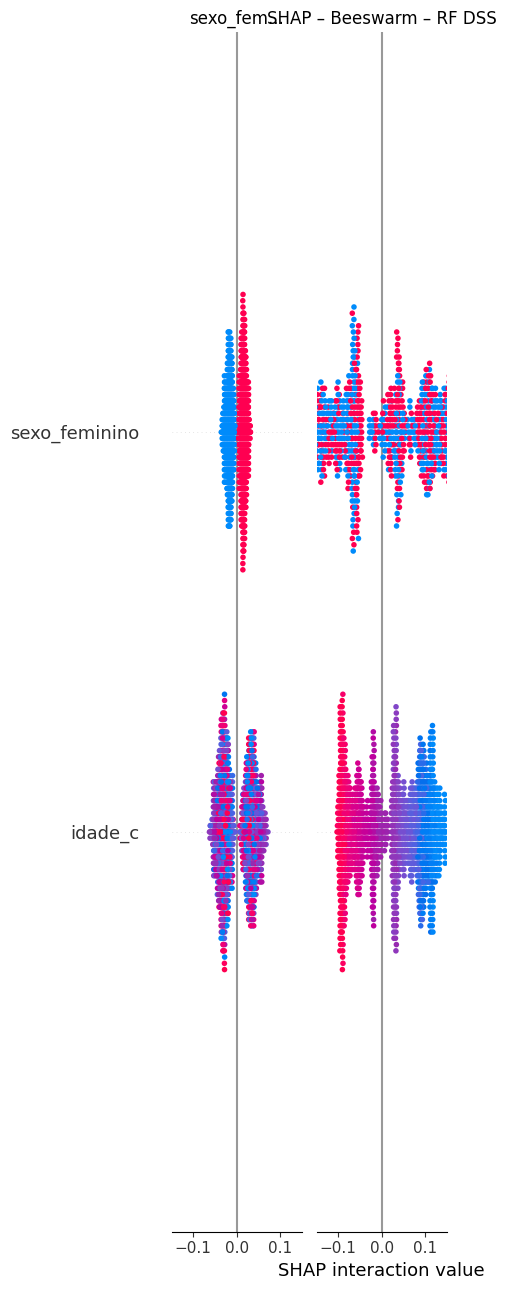


SHAP – Random Forest – DSS+BIO


<Figure size 800x500 with 0 Axes>

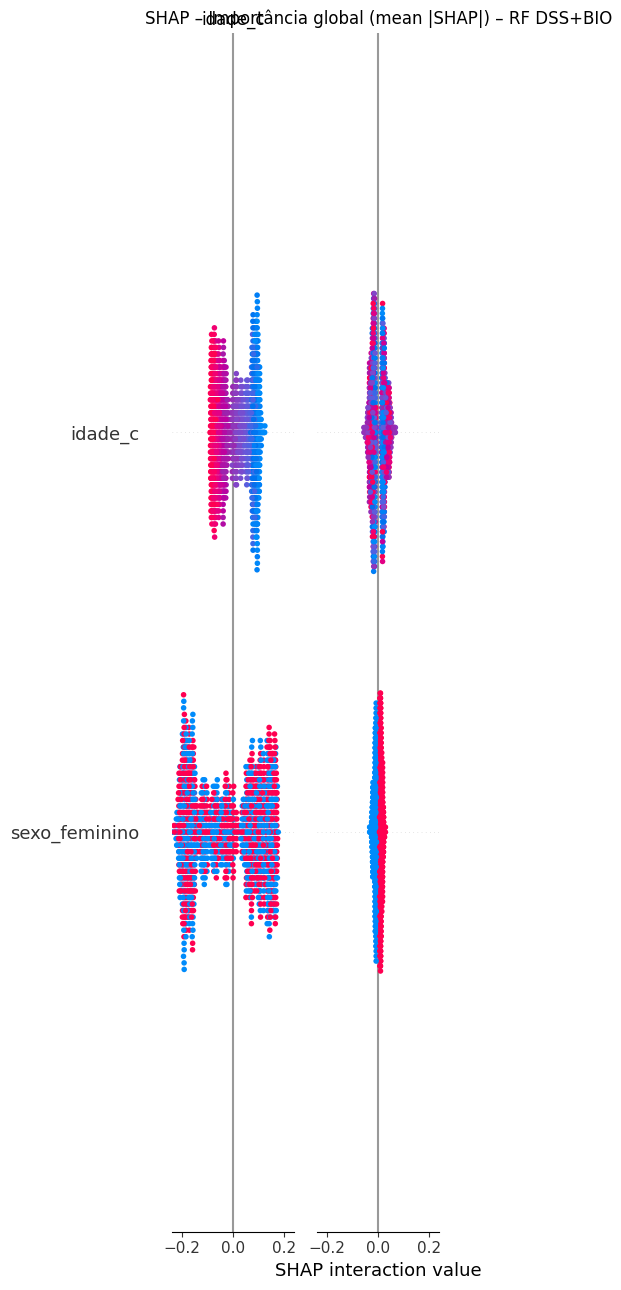

<Figure size 900x600 with 0 Axes>

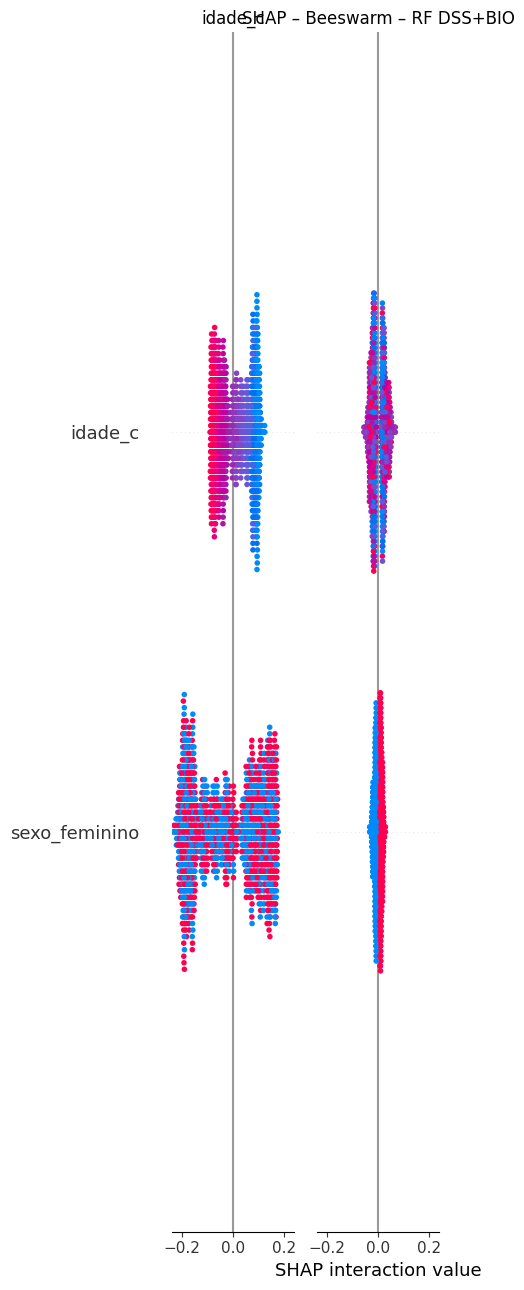

In [26]:
try:
    import shap
except ImportError:
    raise ImportError("Instale o shap com: pip install shap")

for bloco in ["BIO", "DSS", "DSS+BIO"]:
    artefatos = resultados_grid[bloco]["Random Forest"]
    pipeline = artefatos["best_model"]
    X_test = artefatos["X_test"]

    imputer = pipeline.named_steps["imputer"]
    modelo_rf = pipeline.named_steps["model"]

    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index,
    )

    # Amostrar para eficiência (máx 1500 obs)
    n_shap = min(1500, len(X_test_imp))
    X_shap = X_test_imp.sample(n=n_shap, random_state=42)

    explainer = shap.TreeExplainer(modelo_rf)
    sv_raw = explainer.shap_values(X_shap)

    # TreeExplainer retorna lista [classe_0, classe_1] para classificação binária
    sv = sv_raw[1] if isinstance(sv_raw, list) else sv_raw

    print(f"\n{'='*60}")
    print(f"SHAP – Random Forest – {bloco}")

    # Gráfico de barras: importância global média |SHAP|
    plt.figure(figsize=(8, 5))
    shap.summary_plot(sv, X_shap, plot_type="bar", show=False, max_display=15)
    plt.title(f"SHAP – Importância global (mean |SHAP|) – RF {bloco}")
    plt.tight_layout()
    plt.show()

    # Beeswarm: direção e magnitude por variável
    plt.figure(figsize=(9, 6))
    shap.summary_plot(sv, X_shap, show=False, max_display=15)
    plt.title(f"SHAP – Beeswarm – RF {bloco}")
    plt.tight_layout()
    plt.show()


Prevalência de hipertensão na amostra: 28.7%
Razão de Prevalência – Regressão de Poisson Modificada (variância robusta HC0)
Referência: Zou (2004), Am J Epidemiol



,RP,IC_95%_inf,IC_95%_sup,p_valor
escolaridade_ord,0.9416,0.9286,0.9548,0.0000
renda_per_capita_log,0.9883,0.9788,0.9980,0.0177
plano_saude,0.9858,0.9595,1.0128,0.3009
situacao_domicilio,1.0288,1.0028,1.0554,0.0295
idade_c,1.0391,1.0383,1.0398,0.0000
sexo_feminino,1.2362,1.2097,1.2634,0.0000
atividade_ativo,1.0262,1.0033,1.0497,0.0249
tabagismo_ativo,0.9603,0.9271,0.9947,0.0240
alcool_ativo,0.9675,0.9439,0.9917,0.0088
imc,1.0618,1.0599,1.0637,0.0000


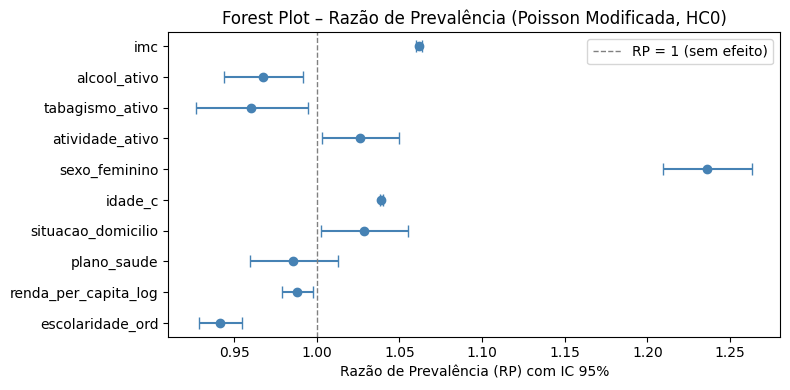

In [27]:
import statsmodels.api as sm

# Variáveis de interesse para o modelo de Razão de Prevalência
vars_rp = [
    "escolaridade_ord", "renda_per_capita_log", "plano_saude",
    "situacao_domicilio", "idade_c", "sexo_feminino",
    "atividade_ativo", "tabagismo_ativo", "alcool_ativo", "imc",
]
vars_rp = [v for v in vars_rp if v in df.columns]

X_rp = df[vars_rp].copy()
y_rp = pd.to_numeric(df["hipertensao"], errors="coerce")

# Limpeza robusta para evitar dtype=object no statsmodels
X_rp = X_rp.replace([np.inf, -np.inf], np.nan)
X_rp = pd.get_dummies(X_rp, drop_first=True, dtype=float)
X_rp = X_rp.apply(pd.to_numeric, errors="coerce")

mask_rp = X_rp.notna().all(axis=1) & y_rp.notna()
X_rp = X_rp.loc[mask_rp].astype(float)
y_rp = y_rp.loc[mask_rp].astype(int)

X_rp_const = sm.add_constant(X_rp, has_constant="add")

modelo_poisson = sm.GLM(
    y_rp,
    X_rp_const,
    family=sm.families.Poisson(),
).fit(cov_type="HC0")

ci = modelo_poisson.conf_int()
rp_table = pd.DataFrame({
    "RP": np.exp(modelo_poisson.params),
    "IC_95%_inf": np.exp(ci.iloc[:, 0]),
    "IC_95%_sup": np.exp(ci.iloc[:, 1]),
    "p_valor": modelo_poisson.pvalues,
}).drop(index="const", errors="ignore").round(4)

prevalencia = y_rp.mean() * 100
print(f"Prevalência de hipertensão na amostra: {prevalencia:.1f}%")
print("Razão de Prevalência – Regressão de Poisson Modificada (variância robusta HC0)")
print("Referência: Zou (2004), Am J Epidemiol\n")
display(rp_table)

# Forest Plot
fig, ax = plt.subplots(figsize=(8, max(4, len(rp_table) * 0.4)))
variaveis = rp_table.index.tolist()
y_pos = list(range(len(variaveis)))

ax.errorbar(
    rp_table["RP"],
    y_pos,
    xerr=[
        (rp_table["RP"] - rp_table["IC_95%_inf"]).clip(lower=0),
        (rp_table["IC_95%_sup"] - rp_table["RP"]).clip(lower=0),
    ],
    fmt="o",
    color="steelblue",
    capsize=4,
    linewidth=1.5,
)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label="RP = 1 (sem efeito)")
ax.set_yticks(y_pos)
ax.set_yticklabels(variaveis)
ax.set_xlabel("Razão de Prevalência (RP) com IC 95%")
ax.set_title("Forest Plot – Razão de Prevalência (Poisson Modificada, HC0)")
ax.legend()
plt.tight_layout()
plt.show()


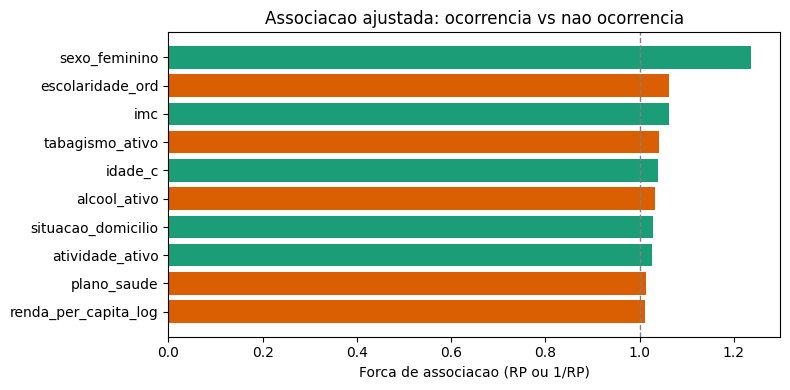

,RP,IC_95%_inf,IC_95%_sup,p_valor,sentido,forca_associacao
sexo_feminino,1.2362,1.2097,1.2634,0.0000,Maior ocorrencia,1.2362
escolaridade_ord,0.9416,0.9286,0.9548,0.0000,Maior nao ocorrencia,1.0620
imc,1.0618,1.0599,1.0637,0.0000,Maior ocorrencia,1.0618
tabagismo_ativo,0.9603,0.9271,0.9947,0.0240,Maior nao ocorrencia,1.0413
idade_c,1.0391,1.0383,1.0398,0.0000,Maior ocorrencia,1.0391
alcool_ativo,0.9675,0.9439,0.9917,0.0088,Maior nao ocorrencia,1.0336
situacao_domicilio,1.0288,1.0028,1.0554,0.0295,Maior ocorrencia,1.0288
atividade_ativo,1.0262,1.0033,1.0497,0.0249,Maior ocorrencia,1.0262
plano_saude,0.9858,0.9595,1.0128,0.3009,Maior nao ocorrencia,1.0144
renda_per_capita_log,0.9883,0.9788,0.9980,0.0177,Maior nao ocorrencia,1.0118


In [28]:
if "rp_table" not in globals():
    raise RuntimeError("Execute primeiro a celula de Razao de Prevalencia (RP).")

rp_adj = rp_table.copy()
rp_adj = rp_adj.loc[rp_adj.index != "const"].copy()

rp_adj["sentido"] = np.where(rp_adj["RP"] >= 1, "Maior ocorrencia", "Maior nao ocorrencia")
rp_adj["forca_associacao"] = np.where(rp_adj["RP"] >= 1, rp_adj["RP"], 1.0 / rp_adj["RP"])
rp_adj = rp_adj.sort_values("forca_associacao", ascending=True)

cores = np.where(rp_adj["sentido"] == "Maior ocorrencia", "#1b9e77", "#d95f02")

plt.figure(figsize=(8, max(4, len(rp_adj) * 0.35)))
plt.barh(rp_adj.index, rp_adj["forca_associacao"], color=cores)
plt.axvline(1.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Forca de associacao (RP ou 1/RP)")
plt.title("Associacao ajustada: ocorrencia vs nao ocorrencia")
plt.tight_layout()
plt.show()

display(
    rp_adj[["RP", "IC_95%_inf", "IC_95%_sup", "p_valor", "sentido", "forca_associacao"]]
    .sort_values("forca_associacao", ascending=False)
    .round(4)
)

## RP ajustada para efeitos inversos (protecao)

Para variaveis com `RP < 1`, mostramos tambem a forca inversa (`1/RP`), que representa quanto a variavel se associa a nao ocorrencia do desfecho.

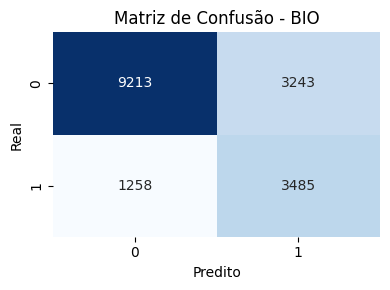

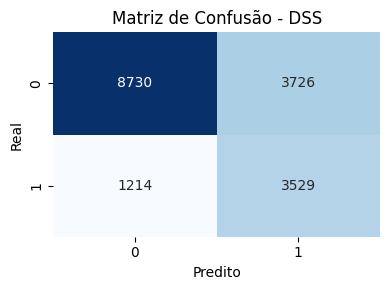

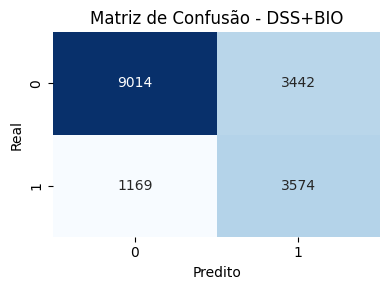

In [29]:
# Exibir matriz de confusão para cada bloco/modelo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if "avaliacoes" not in globals():
    raise RuntimeError("Execute primeiro a célula de avaliação dos modelos para gerar as métricas.")

for bloco in ["BIO", "DSS", "DSS+BIO"]:
    met = avaliacoes[bloco]["Random Forest"]
    cm = met["cm"]
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Matriz de Confusão - {bloco}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


Matriz de Confusão - BIO (valores absolutos):
[[9213 3243]
 [1258 3485]]


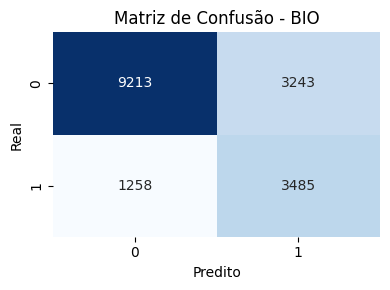


Matriz de Confusão - DSS (valores absolutos):
[[8730 3726]
 [1214 3529]]


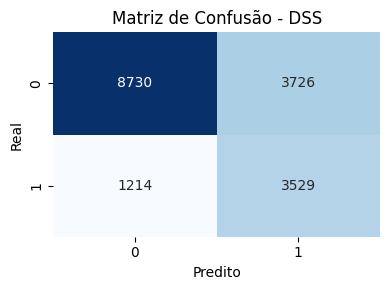


Matriz de Confusão - DSS+BIO (valores absolutos):
[[9014 3442]
 [1169 3574]]


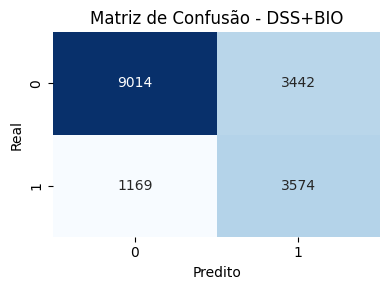

In [30]:
# Exibir matriz de confusão para cada bloco/modelo (gráfico e texto)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if "avaliacoes" not in globals():
    raise RuntimeError("Execute primeiro a célula de avaliação dos modelos para gerar as métricas.")

for bloco in ["BIO", "DSS", "DSS+BIO"]:
    met = avaliacoes[bloco]["Random Forest"]
    cm = met["cm"]
    print(f"\nMatriz de Confusão - {bloco} (valores absolutos):\n{cm}")
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Matriz de Confusão - {bloco}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

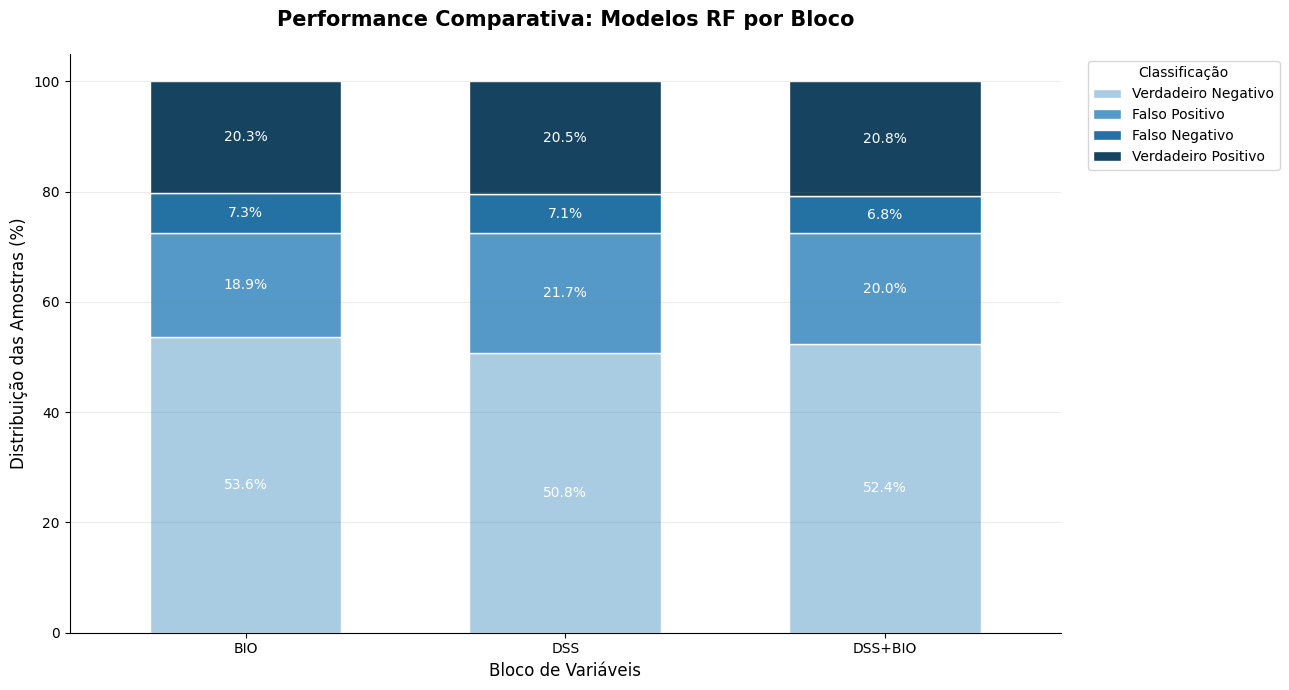

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

# 1. DataFrame com os resultados reais
dados_reais = {
    'Bloco': ['BIO', 'DSS', 'DSS+BIO'],
    'Verdadeiro Negativo': [9213, 8730, 9014],
    'Falso Positivo': [3243, 3726, 3442],
    'Falso Negativo': [1258, 1214, 1169],
    'Verdadeiro Positivo': [3485, 3529, 3574]
}

df_plot = pd.DataFrame(dados_reais).set_index('Bloco')

# Normalização para 100%
df_plot_pct = df_plot.div(df_plot.sum(axis=1), axis=0) * 100

# 2. Usa tons sequenciais da paleta do projeto para as 4 classes
cores = get_palette("sequential")[1:5]

ax = df_plot_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(13, 7),
    color=cores,
    width=0.6,
    edgecolor='white'
)

# 3. Rótulos de porcentagem dentro das fatias
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 4:
        ax.text(x + width / 2, y + height / 2, f'{height:.1f}%',
                ha='center', va='center', fontsize=10, color='white')

# 4. Estética
plt.title("Performance Comparativa: Modelos RF por Bloco", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Distribuição das Amostras (%)", fontsize=12)
plt.xlabel("Bloco de Variáveis", fontsize=12)
plt.xticks(rotation=0)
ax.grid(axis='y', color='gray', alpha=0.15, linewidth=0.8)
plt.legend(title="Classificação", bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

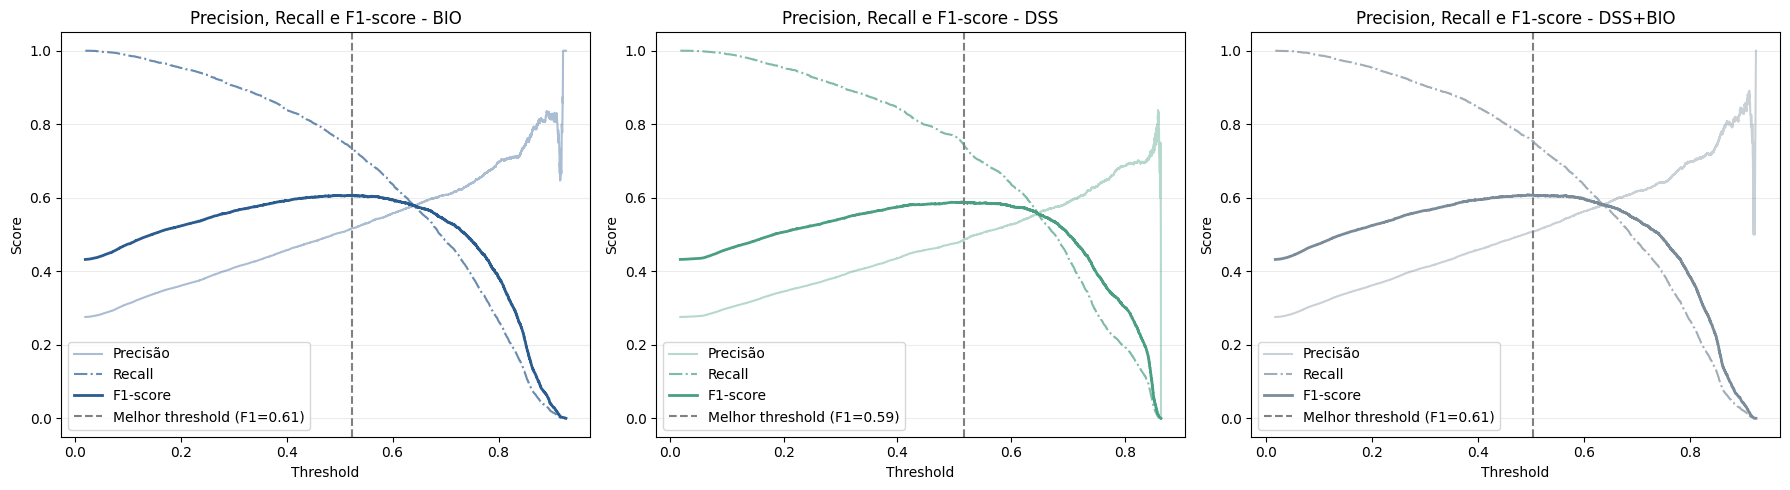

In [44]:
from pathlib import Path
import sys

try:
    from src.plot_palettes import get_palette
except ModuleNotFoundError:
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    from src.plot_palettes import get_palette

palette = get_palette("categorical")
model_color_map = {
    "BIO":     palette[0],
    "DSS":     palette[1],
    "DSS+BIO": palette[2],
}

thresholds_rf = [
    avaliacoes["BIO"]["Random Forest"].get("thresholds"),
    avaliacoes["DSS"]["Random Forest"].get("thresholds"),
    avaliacoes["DSS+BIO"]["Random Forest"].get("thresholds"),
]
precisions_rf = [
    avaliacoes["BIO"]["Random Forest"].get("precisions"),
    avaliacoes["DSS"]["Random Forest"].get("precisions"),
    avaliacoes["DSS+BIO"]["Random Forest"].get("precisions"),
]
recalls_rf = [
    avaliacoes["BIO"]["Random Forest"].get("recalls"),
    avaliacoes["DSS"]["Random Forest"].get("recalls"),
    avaliacoes["DSS+BIO"]["Random Forest"].get("recalls"),
]
f1_scores_rf = [
    avaliacoes["BIO"]["Random Forest"].get("f1_scores"),
    avaliacoes["DSS"]["Random Forest"].get("f1_scores"),
    avaliacoes["DSS+BIO"]["Random Forest"].get("f1_scores"),
]
best_thresholds_rf = [
    avaliacoes["BIO"]["Random Forest"]["threshold_f1"],
    avaliacoes["DSS"]["Random Forest"]["threshold_f1"],
    avaliacoes["DSS+BIO"]["Random Forest"]["threshold_f1"],
]
best_f1s_rf = [
    avaliacoes["BIO"]["Random Forest"]["f1_max"],
    avaliacoes["DSS"]["Random Forest"]["f1_max"],
    avaliacoes["DSS+BIO"]["Random Forest"]["f1_max"],
]
model_names_rf = ["BIO", "DSS", "DSS+BIO"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i in range(3):
    if thresholds_rf[i] is not None:
        cor = model_color_map.get(model_names_rf[i], palette[3])
        axes[i].plot(thresholds_rf[i], precisions_rf[i][:-1], label='Precisão', color=cor, alpha=0.4)
        axes[i].plot(thresholds_rf[i], recalls_rf[i][:-1], label='Recall', color=cor, alpha=0.7, linestyle='-.')
        axes[i].plot(thresholds_rf[i], f1_scores_rf[i][:-1], label='F1-score', color=cor, linewidth=2)
        axes[i].axvline(best_thresholds_rf[i], color='gray', linestyle='--', label=f'Melhor threshold (F1={best_f1s_rf[i]:.2f})')
        axes[i].set_xlabel('Threshold')
        axes[i].set_ylabel('Score')
        axes[i].set_title(f'Precision, Recall e F1-score - {model_names_rf[i]}')
        axes[i].grid(axis='y', color='gray', alpha=0.15, linewidth=0.8)
        axes[i].legend()
plt.tight_layout()
plt.show()